<link href="https://fonts.googleapis.com/css2?family=Roboto:ital,wght@0,100..900;1,100..900&display=swap" rel="stylesheet">

<h1 style="font-family:Arial;"> <center>Google Data Analytics Capstone: Complete a Case Study</center> </h1>
<p><center style="font-family:Arial; font-size:20px;">Case Study 1: How does a bike-share navigate speedy success?</center></p>




<center><img src='https://media0.giphy.com/media/v1.Y2lkPTc5MGI3NjExaDd5ZjVveG52NGlybGl5MjBheHE5Nzd1ajBmOTIwbGc5amxhbWxjaCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/TqVb8jlyJlNNCpEK15/giphy.gif' height=200px width=300px></center>

***


<p><center style="font-family:Arial; font-size:40px;">Overview </center></p>

<div style="background-color:#d4f1f4; padding: 20px; border-radius:15px;">
<p style="font-size:20px; font-family:Arial; line-height: 1.7em">This case study is the capstone project of the Google Data Analytics Professional Certificate, simulating a real-world analytics engagement for Cyclistic, a fictional Chicago bike-share company. The goal is to understand how casual riders and annual members use the service differently — and use those insights to design a data-driven marketing strategy to convert casual riders into members, following the Ask, Prepare, Process, Analyze, Share, and Act framework.</p>



# **Ask**

<div style="background-color:#FAD6D6; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
    
## Business Task
Cyclistic's Director of Marketing, Lily Moreno, believes the company's future growth depends on increasing the number of annual memberships rather than acquiring entirely new customers. Since casual riders are already familiar with and engaged with the Cyclistic service, converting them into annual members represents a high-value, low-friction growth opportunity.
To support this strategy, the marketing analytics team must answer three guiding questions:

* How do annual members and casual riders use Cyclistic bikes differently?
* Why would casual riders buy Cyclistic annual memberships?
* How can Cyclistic use digital media to influence casual riders to become members?

As a junior data analyst on the team, I have been assigned the first question:

*How do annual members and casual riders use Cyclistic bikes differently?*

The insights generated from this analysis will serve as the foundation for a new marketing strategy aimed at converting casual riders into annual members — a strategy that must ultimately be approved by Cyclistic's executive team based on compelling data and clear visual evidence.

## Stakeholders

* Lily Moreno – Director of Marketing; sets the strategic direction and will use the findings to shape the marketing campaign.
* Cyclistic Marketing Analytics Team – Responsible for collecting, analyzing, and reporting the data that informs marketing decisions.
* Cyclistic Executive Team – A detail-oriented group that will review and approve (or reject) the final recommendations.

## How These Insights Drive Business Decisions
Understanding the behavioral differences between casual riders and annual members — such as ride frequency, trip duration, bike type preference, time of day/week, and seasonal patterns — will allow Moreno's team to design targeted, relevant marketing messages and channels. Rather than a one-size-fits-all campaign, the strategy can be tailored to address the specific motivations and usage habits of casual riders, increasing the likelihood of converting them into loyal, higher-revenue annual members.

## Deliverable
A clear statement of the business task: Analyze historical Cyclistic trip data to identify and explain the key differences in bike usage behavior between casual riders and annual members, in order to inform a marketing strategy that converts casual riders into annual members.

# **Prepare**

<div style="background-color:#D6EFD8; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
    
## Data Source & Location
For this analysis, I used Cyclistic's historical trip data, made publicly available by Motivate International Inc. under their data license. I downloaded the data  directly from the company's public data repository and stored the files locally in a dedicated project folder, organized by month, to keep raw data separate from any processed versions, Afterwards the dataset was created on Kaggle to allow this notebook to funcion. The dataset consit of data from January 2023 to May 2026.

## Data Organization

The data is divided into separate CSV files for each month, with each file containing individual ride-level records. Each row represents a single bike trip and typically includes fields such as:

* Ride ID (unique identifier)
* Rideable type (classic bike, electric bike, etc.)
* Start and end timestamps
* Start and end station names and IDs
* Start and end latitude/longitude coordinates
* Rider type (member or casual)

This structure makes the dataset wide and long enough to support trend analysis across time, location, and customer segment, while still being manageable at the row level for cleaning and transformation.

## Credibility and ROCCC Assessment

Evaluating the dataset against the ROCCC framework:

* Reliable – The data is collected directly from Cyclistic's own bike-share system, capturing actual ride transactions rather than survey or self-reported data, making it accurate and dependable.
* Original – The data originates from the primary source (Motivate International Inc., operator of the bike-share system), not a third party or secondary aggregator.
* Comprehensive – The dataset includes all relevant fields needed to address the business question, such as ride times, durations, station locations, and rider type.
* Current – Using the most recent 12 months ensures the analysis reflects up-to-date rider behavior and seasonal patterns.
* Cited – The data is properly licensed and attributed to Motivate International Inc., with clear sourcing.

Overall, the dataset is credible and well-suited to this analysis.

## Licensing, Privacy, and Security
The data is provided under Motivate International Inc.'s public data license, which permits its use for this type of analysis. Importantly, the dataset does not include any personally identifiable information (PII), such as names, payment details, or credit card numbers. This means I cannot determine whether casual riders live within the Cyclistic service area or whether the same individual purchased multiple single-ride passes. This is a known limitation acknowledged upfront, and the analysis is scoped accordingly to rely only on the behavioral and trip-level data available.

## Data Integrity Verification

Exploratory data analysis (EDA) will be performed to verify data integrity by identifying inconsistencies, missing values, outliers, and duplicate entries.

## Relevance to the Business Question
The dataset is well-suited to answering the assigned question. The available fields allow for direct comparison between the two rider types across ride duration, time of day, day of week, seasonal trends, bike type preference, and popular stations — all of which are central to building a behavior-based marketing strategy.

In [1]:
# Importing Data Science Libraries
import numpy as np
import pandas as pd
import os

# Importing Visualization Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as px
import missingno as msno
import plotly.offline as pyo 
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from plotly.subplots import make_subplots


import warnings
warnings.filterwarnings('ignore')

<div style="background-color:#D6EFD8; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
Uploaded and confirmed that all 12 monthly files had consistent column names and data types across the full year.


In [2]:
# Set the directory you want to start from
rootDir = '/kaggle/input/datasets/michal58pekala/data-analytics-capstone-bike-share-dataset'
# List to store all dataframes
dfs = []
# Loop through files to add them to the list
for root, dirs, files in os.walk(rootDir):
    files.sort(reverse=True)  # Sort filenames alphabetically
    for file in files[:12]:
        if file.endswith('.csv'):
            if file.startswith('2025') or file.startswith('2026'):
                path = os.path.join(root, file)
                print("Loading:", path)
                dfs.append(pd.read_csv(path))
#The loading progress of the files
print(f"\nLoaded {len(dfs)} CSV files")
# Concatanate all files
dataset = pd.concat(dfs, ignore_index=True)
# To check the combined data
print("\nCombined dataset shape:", dataset.shape)
dataset.head()

Loading: /kaggle/input/datasets/michal58pekala/data-analytics-capstone-bike-share-dataset/Divvy_trip_data/202605-divvy-tripdata.csv
Loading: /kaggle/input/datasets/michal58pekala/data-analytics-capstone-bike-share-dataset/Divvy_trip_data/202604-divvy-tripdata.csv
Loading: /kaggle/input/datasets/michal58pekala/data-analytics-capstone-bike-share-dataset/Divvy_trip_data/202603-divvy-tripdata.csv
Loading: /kaggle/input/datasets/michal58pekala/data-analytics-capstone-bike-share-dataset/Divvy_trip_data/202602-divvy-tripdata.csv
Loading: /kaggle/input/datasets/michal58pekala/data-analytics-capstone-bike-share-dataset/Divvy_trip_data/202601-divvy-tripdata.csv
Loading: /kaggle/input/datasets/michal58pekala/data-analytics-capstone-bike-share-dataset/Divvy_trip_data/202512-divvy-tripdata.csv
Loading: /kaggle/input/datasets/michal58pekala/data-analytics-capstone-bike-share-dataset/Divvy_trip_data/202511-divvy-tripdata.csv
Loading: /kaggle/input/datasets/michal58pekala/data-analytics-capstone-bike-

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,E8847A2B0FD51251,electric_bike,2026-05-20 11:36:57.782,2026-05-20 11:37:17.020,NaN,NaN,NaN,NaN,41.89,-87.62,41.89,-87.62,casual
1,746948BC4E29B6D0,electric_bike,2026-05-20 11:37:45.232,2026-05-20 11:51:43.399,NaN,NaN,NaN,NaN,41.89,-87.62,41.90,-87.64,casual
2,33E3CE21C190985E,electric_bike,2026-05-20 18:37:05.606,2026-05-20 18:48:39.956,NaN,NaN,NaN,NaN,41.91,-87.63,41.93,-87.64,casual
3,63D3912D5A15ED09,electric_bike,2026-05-20 08:00:52.487,2026-05-20 08:09:58.630,NaN,NaN,NaN,NaN,41.91,-87.63,41.89,-87.64,casual
4,76EBC4E28ABC6A5E,electric_bike,2026-05-19 19:39:44.270,2026-05-19 20:06:45.976,NaN,NaN,NaN,NaN,41.91,-87.63,41.91,-87.63,casual


<div style="background-color:#D6EFD8; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
Checked for missing or null values, particularly in key fields such as station names, ride timestamps, and rider type.

In [3]:
# Get the count of non-null values for each column
non_null_counts = dataset.count()

# Calculate the count of null values for each column
null_counts = dataset.isnull().sum()

# Create the figure with two traces, one for non-null values and one for null values
fig = go.Figure(data=[
    go.Bar(name='Non-null values', x=non_null_counts.index, y=non_null_counts.values),
    go.Bar(name='Missing values', x=null_counts.index, y=null_counts.values)
])

# Change the bar mode to 'stack'
fig.update_layout(barmode='stack')

# Add axis labels and title
fig.update_layout(
    xaxis_title="Column",
    yaxis_title="Count",
    title="Number of Non-null and Missing Rows per Column",
    title_font=dict(size=20),
    font=dict(size=14),
    height=600,
    template='seaborn'
)

# Show the chart
fig.show()

In [4]:
# Calculate the percentage of missing data
missing_data = dataset.isnull().mean() * 100

# Filter out columns with no missing data
missing_data = missing_data[missing_data != 0]

# Convert the Series to a DataFrame
missing_data_df = missing_data.reset_index().rename(columns={'index': 'column', 0: 'missing_percentage'})

# Create a bar plot
fig = px.bar(missing_data_df, x='column', y='missing_percentage', 
             title='Percentage of missing data by feature',
             labels={'missing_percentage': 'Percentage of missing data (%)', 'column': 'Feature'},
             template='seaborn')

fig.show()

<Axes: >

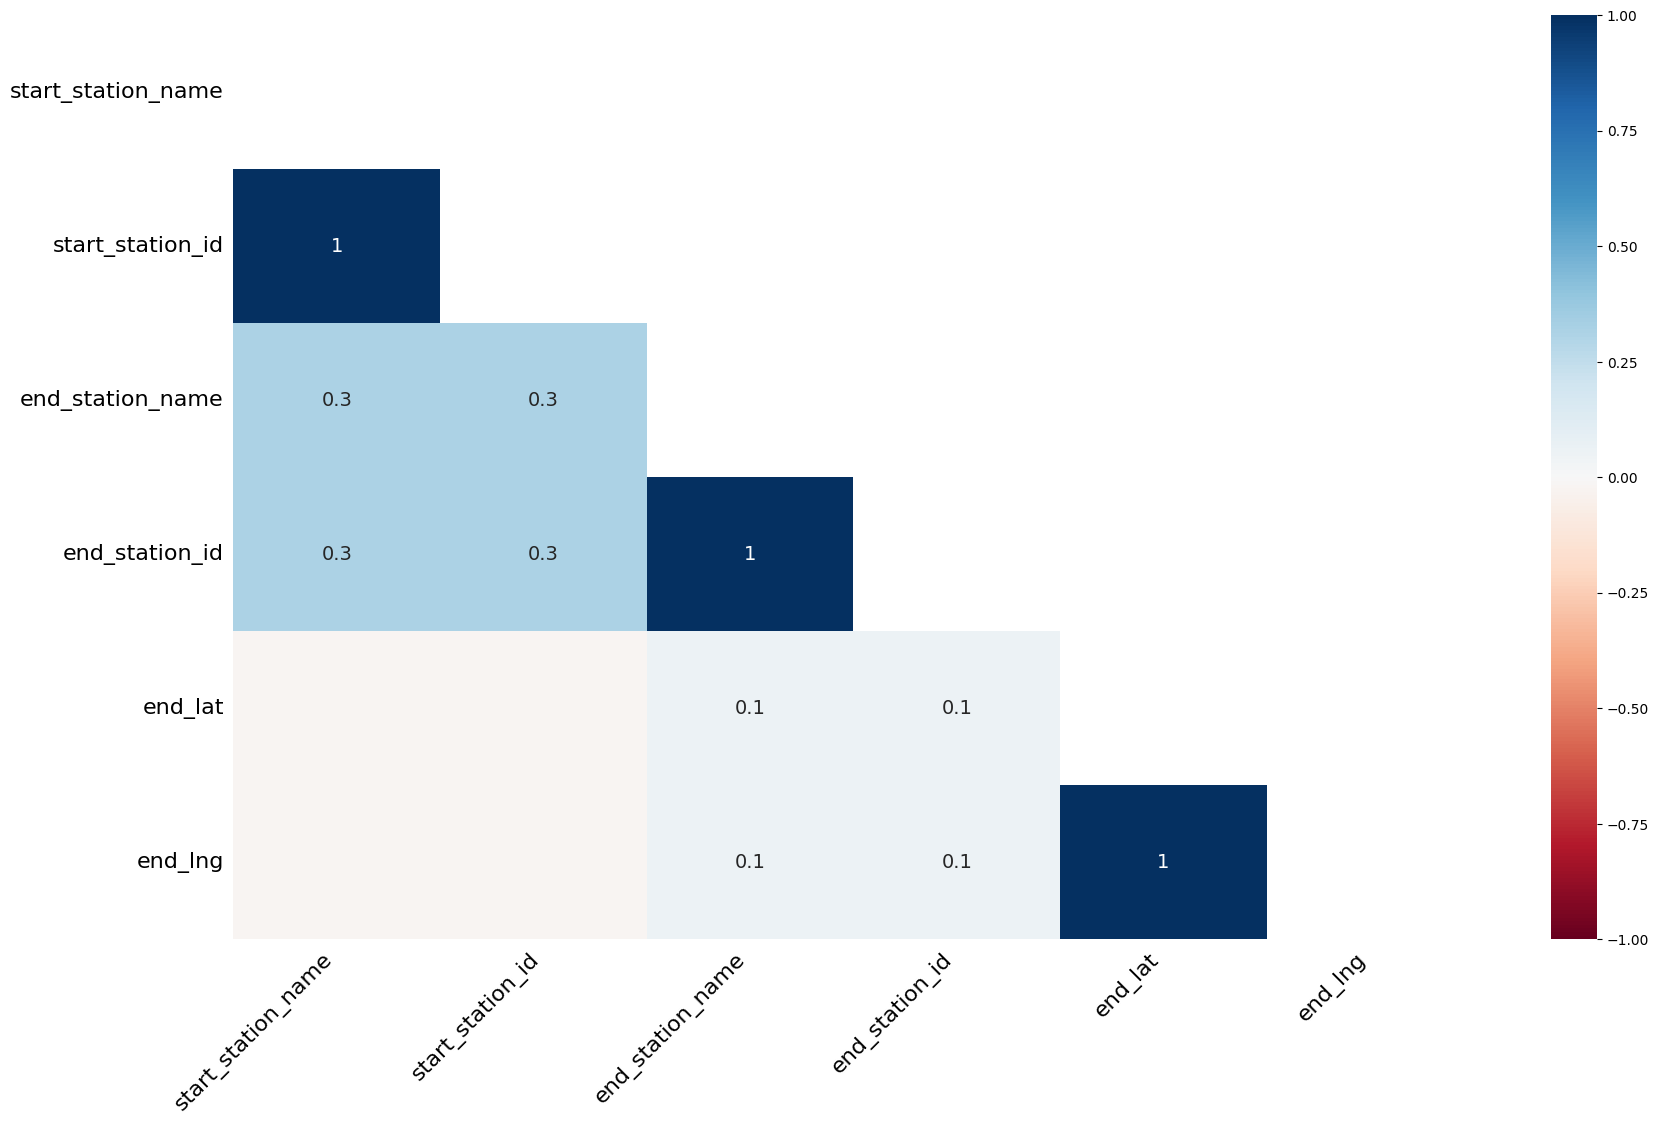

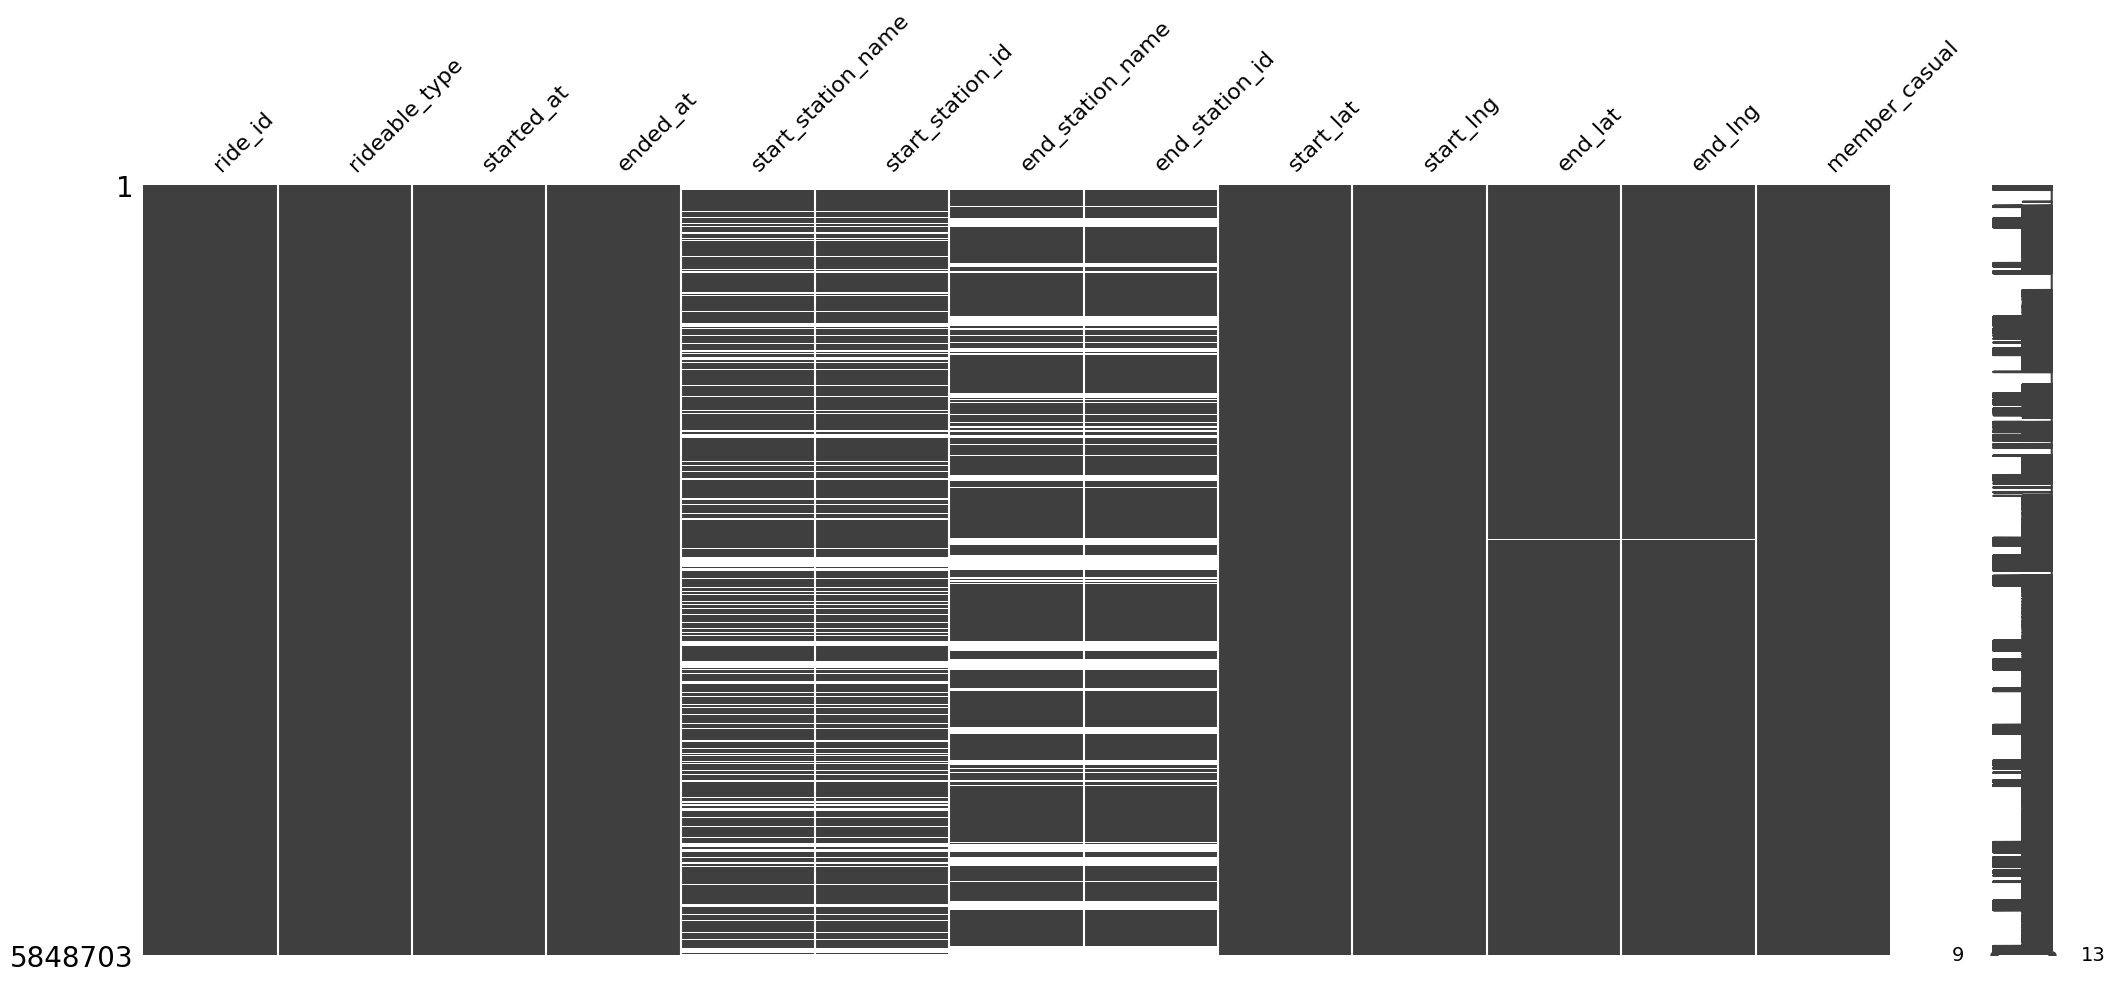

In [5]:
# plot missing data heatmap
msno.heatmap(dataset)

# or plot missing data matrix
msno.matrix(dataset)

<div style="background-color:#D6EFD8; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
The missing data distribution makes recovering station names from station IDs unviable. However, the volume of missing values in the start and end station name columns is too significant to ignore — so an attempt will be made to recover station names by matching the latitude and longitude coordinates of missing entries against the rest of the dataset. Any station names that cannot be recovered through this method will be filled with "Unknown". The missing values in the latitude and longitude columns themselves are negligible by comparison and will simply be dropped.

# **Process**

<div style="background-color:#D6E4F0; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">

## Deliverable

Documentation of all cleaning and manipulation steps: The raw 12-month Cyclistic trip dataset was cleaned using a four-step sklearn Pipeline in Python. Steps addressed missing geographic data, missing station names (recovered via GPS coordinate matching where possible), duplicate ride records, and invalid trip durations. A trip_duration_mins column was added as a derived analytical metric. All transformations were implemented in a reproducible, auditable pipeline structure.

## Data Cleaning Steps
The cleaning process was implemented as a four-step pipeline:

Step 1 — Drop missing coordinates. Rows where end_lat or end_lng were null were removed, as trips with no recorded end location have no geographical value and cannot be recovered.

Step 2 — Recover missing station names. A coordinate-based lookup was built from rows with known station names, mapping rounded GPS coordinates (4 decimal places, ±11 metres) to the most frequently recorded name at that location. Missing station names were filled using this lookup where a match was found, with any remaining gaps filled with "Unknown". Records labelled "Unknown" were retained as they still hold valid timestamp, duration, and rider type data.

Step 3 — Remove duplicate ride IDs. Rows with null or duplicate ride_id values were dropped, keeping only the first occurrence of each ID. Duplicates represent logging or transmission errors rather than genuine separate trips.

Step 4 — Filter invalid trip durations. Trip duration was calculated from start and end timestamps. Trips with negative, zero, or sub-60-second durations were removed as non-genuine, as were trips exceeding 24 hours, which likely represent lost or unreturned bikes. A trip_duration_mins column was added following this step for use in the analysis phase.


In [6]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


class DropMissingRows(BaseEstimator, TransformerMixin):
    """Drop rows where critical coordinate fields are missing."""
    def __init__(self, subset=['end_lat', 'end_lng']):
        self.subset = subset

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        before = len(X)
        X = X.dropna(subset=self.subset).reset_index(drop=True)
        after = len(X)
        return X


class FillStationNamesFromCoords(BaseEstimator, TransformerMixin):
    """
    First attempts to fill missing station names by matching on
    rounded lat/lng coordinates. Remaining gaps are filled with fallback value.
    """
    def __init__(self, lat_precision=4, fallback='Unknown'):
        self.lat_precision = lat_precision
        self.fallback      = fallback
        self.start_lookup_ = {}
        self.end_lookup_   = {}

    def fit(self, X, y=None):
        X = X.copy()

        start_known = X[X['start_station_name'].notna()].copy()
        start_known['_lat_r'] = start_known['start_lat'].round(self.lat_precision)
        start_known['_lng_r'] = start_known['start_lng'].round(self.lat_precision)
        self.start_lookup_ = (
            start_known.groupby(['_lat_r', '_lng_r'])['start_station_name']
            .agg(lambda x: x.value_counts().index[0])
            .to_dict()
        )

        end_known = X[X['end_station_name'].notna()].copy()
        end_known['_lat_r'] = end_known['end_lat'].round(self.lat_precision)
        end_known['_lng_r'] = end_known['end_lng'].round(self.lat_precision)
        self.end_lookup_ = (
            end_known.groupby(['_lat_r', '_lng_r'])['end_station_name']
            .agg(lambda x: x.value_counts().index[0])
            .to_dict()
        )

        return self

    def transform(self, X):
        X = X.copy()

        # ── Fill start_station_name ───────────────────────────────
        missing_start       = X['start_station_name'].isna()
        total_missing_start = missing_start.sum()

        filled_start_values = X.loc[missing_start].apply(
            lambda row: self.start_lookup_.get(
                (round(row['start_lat'], self.lat_precision),
                 round(row['start_lng'], self.lat_precision)),
                self.fallback
            ), axis=1
        )
        X.loc[missing_start, 'start_station_name'] = filled_start_values

        start_via_coords   = (filled_start_values != self.fallback).sum()
        start_via_fallback = (filled_start_values == self.fallback).sum()

        # ── Fill end_station_name ─────────────────────────────────
        missing_end       = X['end_station_name'].isna()
        total_missing_end = missing_end.sum()

        filled_end_values = X.loc[missing_end].apply(
            lambda row: self.end_lookup_.get(
                (round(row['end_lat'], self.lat_precision),
                 round(row['end_lng'], self.lat_precision)),
                self.fallback
            ), axis=1
        )
        X.loc[missing_end, 'end_station_name'] = filled_end_values

        end_via_coords   = (filled_end_values != self.fallback).sum()
        end_via_fallback = (filled_end_values == self.fallback).sum()

        # ── Report - I am curious if this method is feasible ───────

        print(f"  {'Recovered via lat/lng':30} {start_via_coords:>10,} {end_via_coords:>10,}")
        print(f"  {'Filled with fallback (Unknown)':30} {start_via_fallback:>10,} {end_via_fallback:>10,}")

        return X


class DropDuplicateRideIDs(BaseEstimator, TransformerMixin):
    """
    Removes duplicate ride_id entries, keeping the first occurrence.
    Duplicate ride IDs indicate data entry errors or system logging issues.
    """
    def __init__(self, ride_id_col='ride_id', keep='first'):
        self.ride_id_col = ride_id_col
        self.keep = keep

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        before = len(X)

        # Check for any malformed ride IDs (nulls or wrong length)
        null_ids = X[self.ride_id_col].isna().sum()
        if null_ids > 0:
            X = X.dropna(subset=[self.ride_id_col])

        X = X.drop_duplicates(subset=[self.ride_id_col], keep=self.keep)
        X = X.reset_index(drop=True)

        after = len(X)
        return X


class FilterInvalidTripDurations(BaseEstimator, TransformerMixin):
    """
    Computes trip duration and removes invalid records:

    - Negative durations       → end_time is before start_time (data error)
    - Zero duration            → bike was undocked and immediately re-docked
    - Under min_duration secs  → too short to be a real trip (default: 60s)
    - Over max_duration secs   → likely an unreturned/stolen bike (default: 24hrs)

    Adds a 'trip_duration_mins' column for downstream analysis.
    """
    def __init__(
        self,
        start_col='started_at',
        end_col='ended_at',
        min_duration_secs=60,       # 1 minute
        max_duration_secs=86400,    # 24 hours
    ):
        self.start_col = start_col
        self.end_col = end_col
        self.min_duration_secs = min_duration_secs
        self.max_duration_secs = max_duration_secs

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        before = len(X)

        # Ensure datetime types
        X[self.start_col] = pd.to_datetime(X[self.start_col])
        X[self.end_col]   = pd.to_datetime(X[self.end_col])

        # Compute duration in seconds
        X['trip_duration_secs'] = (
            X[self.end_col] - X[self.start_col]
        ).dt.total_seconds()

        # Breakdown of what's being removed (for transparency)
        negative = (X['trip_duration_secs'] < 0).sum()
        zero     = (X['trip_duration_secs'] == 0).sum()
        too_short = (
            (X['trip_duration_secs'] > 0) &
            (X['trip_duration_secs'] < self.min_duration_secs)
        ).sum()
        too_long  = (X['trip_duration_secs'] > self.max_duration_secs).sum()

        # Apply filter
        X = X[
            (X['trip_duration_secs'] >= self.min_duration_secs) &
            (X['trip_duration_secs'] <= self.max_duration_secs)
        ].reset_index(drop=True)

        # Convert to minutes for readability
        X['trip_duration_mins'] = (X['trip_duration_secs'] / 60).round(2)
        X = X.drop(columns=['trip_duration_secs'])

        after = len(X)
        return X



# Build and run the full pipeline
pipeline = Pipeline(steps=[
    ('drop_missing_coords', DropMissingRows(subset=['end_lat', 'end_lng'])),
    ('fill_station_names',  FillStationNamesFromCoords(lat_precision=4, fallback='Unknown')),
    ('drop_duplicate_ids',  DropDuplicateRideIDs(ride_id_col='ride_id', keep='first')),
    ('filter_durations',    FilterInvalidTripDurations(
                                min_duration_secs=60,
                                max_duration_secs=86400
                            )),
])

dataset_v1 = pipeline.fit_transform(dataset)


  Recovered via lat/lng                  21         31
  Filled with fallback (Unknown)  1,249,646  1,308,407


<div style="background-color:#D6E4F0; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">

The coordinate-based station name recovery yielded fewer matches than anticipated. It has been kept in the pipeline as it may perform better on larger datasets, though decreasing coordinate precision might improve match rates, there would be a higher risks of incorrectly merging nearby stations.

Following the full cleaning pipeline, there are no remaining missing values in any of the columns used in this analysis.

<Axes: >

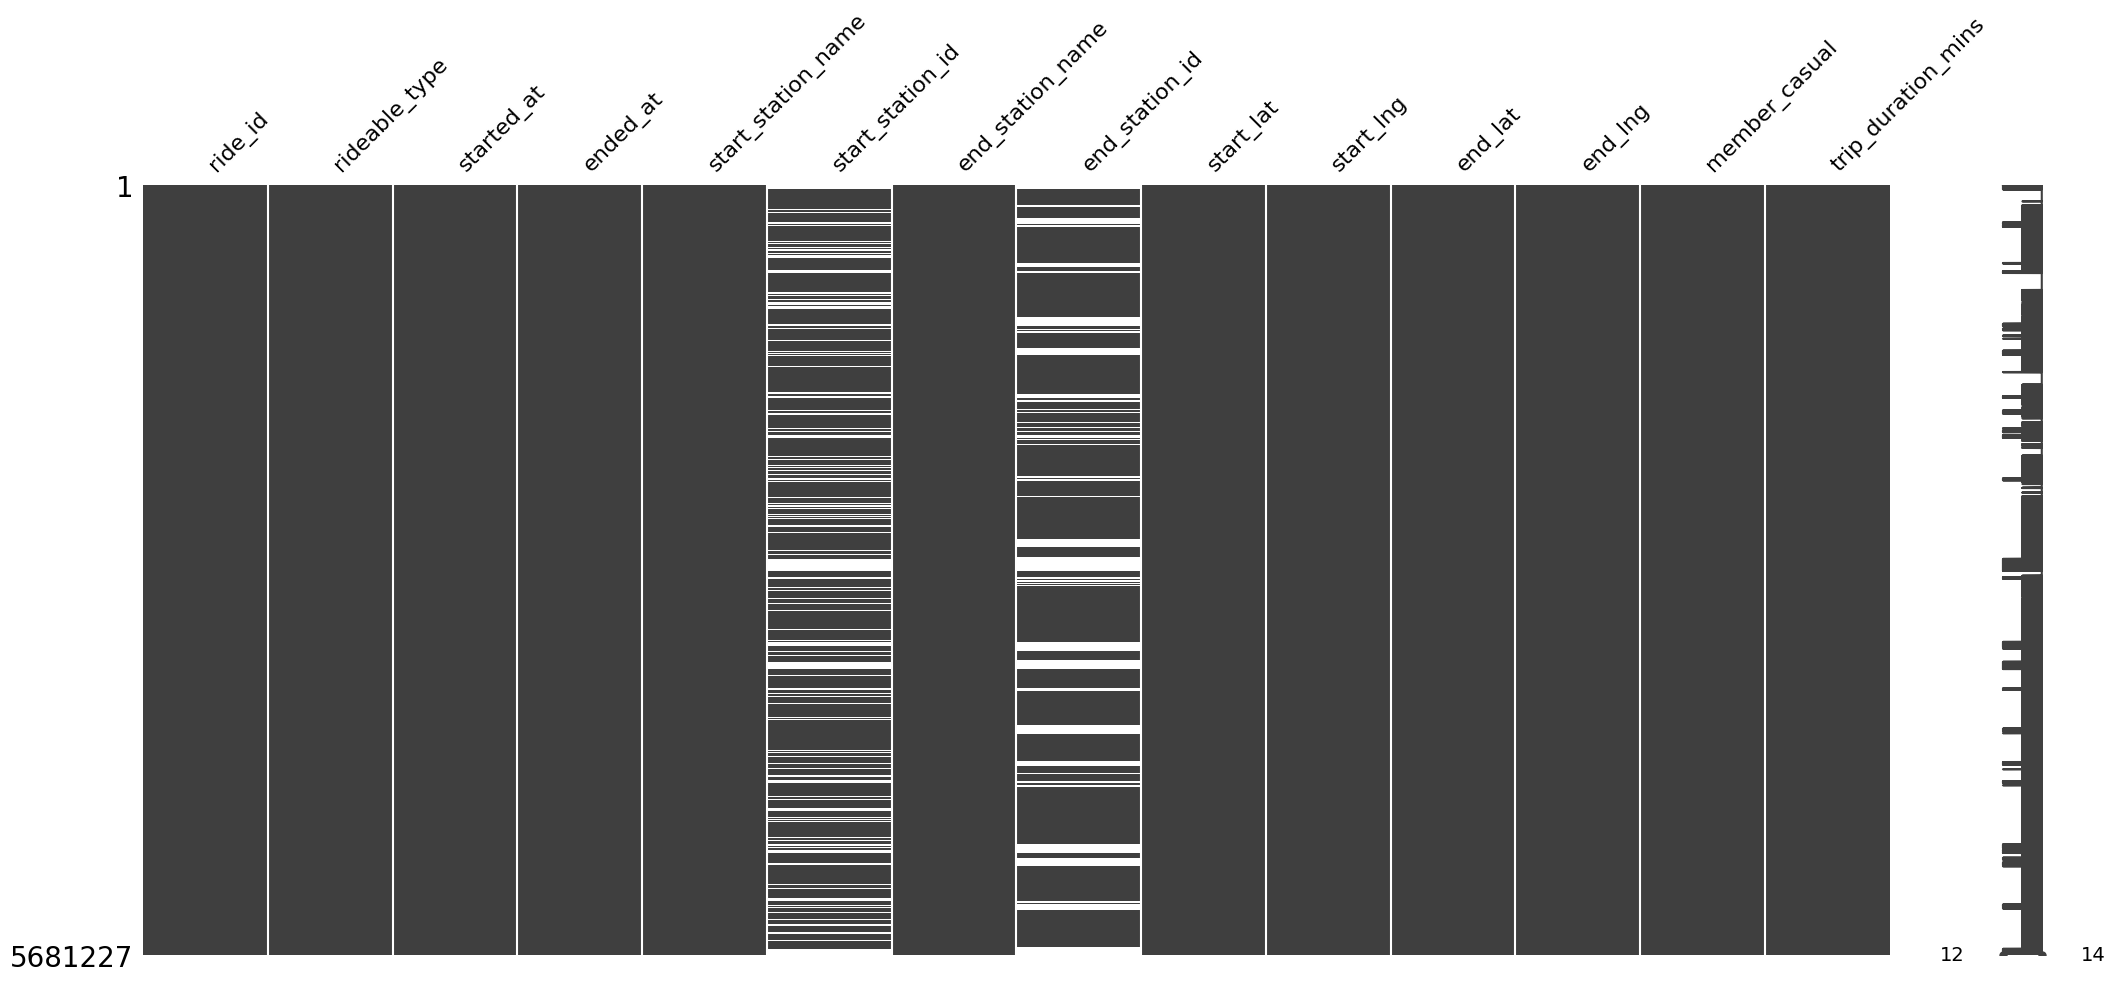

In [7]:
msno.matrix(dataset_v1)

<div style="background-color:#D6E4F0; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
The no longer needed columns are dropped:

In [8]:
def drop_columns(df, cols_to_drop):
    df = df.drop(cols_to_drop, axis=1)
    return df
cols_to_drop = ['start_station_id', 'end_station_id', 'ride_id', 'start_station_id'
               , 'end_station_id']
dataset_v2 = drop_columns(dataset_v1, cols_to_drop)

# Convert 'started_at' and 'ended_at' to datetime
dataset_v2['started_at'] = pd.to_datetime(dataset_v2['started_at'],format='ISO8601')
dataset_v2['ended_at'] = pd.to_datetime(dataset_v2['ended_at'],format='ISO8601')
dataset_v2 = dataset_v2.sort_values('started_at').reset_index(drop=True)
dataset_v2.head()
    

,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_mins
0,classic_bike,2025-05-31 12:27:15.720,2025-06-01 00:46:49.648,Clark St & Lincoln Ave,Ashland Ave & Wellington Ave,41.915689,-87.634600,41.936083,-87.669807,casual,739.57
1,classic_bike,2025-05-31 14:59:20.001,2025-06-01 10:27:15.979,Franklin St & Jackson Blvd,Fairbanks Ct & Grand Ave,41.877708,-87.635321,41.891847,-87.620580,casual,1167.93
2,classic_bike,2025-05-31 16:05:15.133,2025-06-01 12:00:34.996,Michigan Ave & 8th St,Michigan Ave & 8th St,41.872773,-87.623981,41.872773,-87.623981,casual,1195.33
3,classic_bike,2025-05-31 16:09:11.185,2025-06-01 12:00:34.996,Michigan Ave & 8th St,Michigan Ave & 8th St,41.872773,-87.623981,41.872773,-87.623981,casual,1191.40
4,classic_bike,2025-05-31 16:11:30.573,2025-06-01 12:45:33.044,DuSable Lake Shore Dr & North Blvd,DuSable Lake Shore Dr & North Blvd,41.911722,-87.626804,41.911722,-87.626804,casual,1234.04


In [9]:
dataset_v2['start_station_name'].value_counts()

start_station_name
Unknown                               1153021
Navy Pier                               49742
DuSable Lake Shore Dr & Monroe St       40775
Michigan Ave & Oak St                   36075
DuSable Lake Shore Dr & North Blvd      34725
                                       ...   
Public Rack - Bradley Park                  1
Public Rack - Archer Park                   1
Public Rack - Springfield & 71st            1
Public Rack - May St & 63rd St              1
Public Rack - Racine Ave & 76th             1
Name: count, Length: 1926, dtype: int64

<div style="background-color:#D6E4F0; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
Station names appearing fewer than 15,000 times across the dataset are grouped into an 'Other' category to reduce dimensionality and simplify the analysis.

In [10]:
threshold = 15000
dataset_v3 = dataset_v2.copy()
for column in ['start_station_name', 'end_station_name']:
    # get frequency of each label
    freq = dataset_v3[column].value_counts()
    # find labels below threshold
    rare_labels = freq[freq < threshold].index
    # replace rare labels with 'Other'
    dataset_v3[column] = dataset_v3[column].apply(lambda x: 'Other' if x in rare_labels else x)
dataset_v3['start_station_name'].value_counts()

start_station_name
Other                                     3080565
Unknown                                   1153021
Navy Pier                                   49742
DuSable Lake Shore Dr & Monroe St           40775
Michigan Ave & Oak St                       36075
                                           ...   
Franklin St & Jackson Blvd                  15612
Clark St & Schiller St                      15300
DuSable Lake Shore Dr & Wellington Ave      15272
Larrabee St & Webster Ave                   15216
Wells St & Evergreen Ave                    15098
Name: count, Length: 69, dtype: int64

<div style="background-color:#D6E4F0; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
A following set of features was added to support the analysis phase:


* Hour, month and year extracted from the started_at timestamp,
* Day of the week numbered Monday=1 through Sunday=7, with a human-readable day_name column (Mon, Tue…) for use in visualisations,
* Month name column (Jan, Feb…) added alongside the numeric month for chart labelling,
* Ride length category grouping trip durations into seven brackets (<10, 10–20, 20–30, 30–40, 40–50, 50–60, 60+ minutes) using pd.cut(),
* The function operates on a copy of the input dataframe to avoid mutating the cleaned data upstream.

In [11]:
def create_features(df):
    df = df.copy()  

    # --- Time features ---
    df['hour']  = df['started_at'].dt.hour
    df['month'] = df['started_at'].dt.month
    df['year']  = df['started_at'].dt.year

    # --- Day of week (Monday=1, Sunday=7)  ---
    df['day_of_week'] = df['started_at'].dt.dayofweek + 1 

    #  day name for charts
    day_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu',
           5: 'Fri', 6: 'Sat', 7: 'Sun'}
    df['day_name'] = df['day_of_week'].map(day_map)

    #  Add month name for charts
    month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
                 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
                 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
    df['month_name'] = df['month'].map(month_map)

    # --- Ride length bins ---
    ride_bins   = [0, 10, 20, 30, 40, 50, 60, np.inf]
    ride_labels = ['<10', '10-20', '20-30', '30-40', '40-50', '50-60', '60+']
    df['ride_length_category'] = pd.cut(
        df['trip_duration_mins'], ride_bins, labels=ride_labels
    )
    return df

dataset_v4 = create_features(dataset_v3)

dataset_v4.head()

,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration_mins,hour,month,year,day_of_week,day_name,month_name,ride_length_category
0,classic_bike,2025-05-31 12:27:15.720,2025-06-01 00:46:49.648,Clark St & Lincoln Ave,Other,41.915689,-87.634600,41.936083,-87.669807,casual,739.57,12,5,2025,6,Sat,May,60+
1,classic_bike,2025-05-31 14:59:20.001,2025-06-01 10:27:15.979,Franklin St & Jackson Blvd,Fairbanks Ct & Grand Ave,41.877708,-87.635321,41.891847,-87.620580,casual,1167.93,14,5,2025,6,Sat,May,60+
2,classic_bike,2025-05-31 16:05:15.133,2025-06-01 12:00:34.996,Michigan Ave & 8th St,Michigan Ave & 8th St,41.872773,-87.623981,41.872773,-87.623981,casual,1195.33,16,5,2025,6,Sat,May,60+
3,classic_bike,2025-05-31 16:09:11.185,2025-06-01 12:00:34.996,Michigan Ave & 8th St,Michigan Ave & 8th St,41.872773,-87.623981,41.872773,-87.623981,casual,1191.40,16,5,2025,6,Sat,May,60+
4,classic_bike,2025-05-31 16:11:30.573,2025-06-01 12:45:33.044,DuSable Lake Shore Dr & North Blvd,DuSable Lake Shore Dr & North Blvd,41.911722,-87.626804,41.911722,-87.626804,casual,1234.04,16,5,2025,6,Sat,May,60+


<div style="background-color:#D6E4F0; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
And final drop of no longer needed columns. This concludes the manipulating of data.

In [12]:
cols_to_drop = ['started_at', 'ended_at', 'day_of_week'
               , 'month', 'trip_duration_mins']
dataset_final = drop_columns(dataset_v4, cols_to_drop)
dataset_final.head()

,rideable_type,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,member_casual,hour,year,day_name,month_name,ride_length_category
0,classic_bike,Clark St & Lincoln Ave,Other,41.915689,-87.634600,41.936083,-87.669807,casual,12,2025,Sat,May,60+
1,classic_bike,Franklin St & Jackson Blvd,Fairbanks Ct & Grand Ave,41.877708,-87.635321,41.891847,-87.620580,casual,14,2025,Sat,May,60+
2,classic_bike,Michigan Ave & 8th St,Michigan Ave & 8th St,41.872773,-87.623981,41.872773,-87.623981,casual,16,2025,Sat,May,60+
3,classic_bike,Michigan Ave & 8th St,Michigan Ave & 8th St,41.872773,-87.623981,41.872773,-87.623981,casual,16,2025,Sat,May,60+
4,classic_bike,DuSable Lake Shore Dr & North Blvd,DuSable Lake Shore Dr & North Blvd,41.911722,-87.626804,41.911722,-87.626804,casual,16,2025,Sat,May,60+


# **Analyse**
<div style="background-color:#E8D6F0; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
The Analyze phase examines the cleaned and enriched dataset to uncover how casual riders and annual members use Cyclistic bikes differently. This involves three core activities:

* Descriptive analysis — summarising the central tendencies and distributions of key variables such as ride length, time of day, and day of week to establish a baseline picture of each rider group
* Trend identification — examining how usage patterns shift across hours, days, months, and locations to surface behavioural differences between the two groups
* Aggregation and comparison — grouping and cross-tabulating the data by rider type to directly compare habits, preferences, and usage frequency

Together these activities build the evidence base needed to answer the central business question and inform the marketing recommendations in the Act phase.


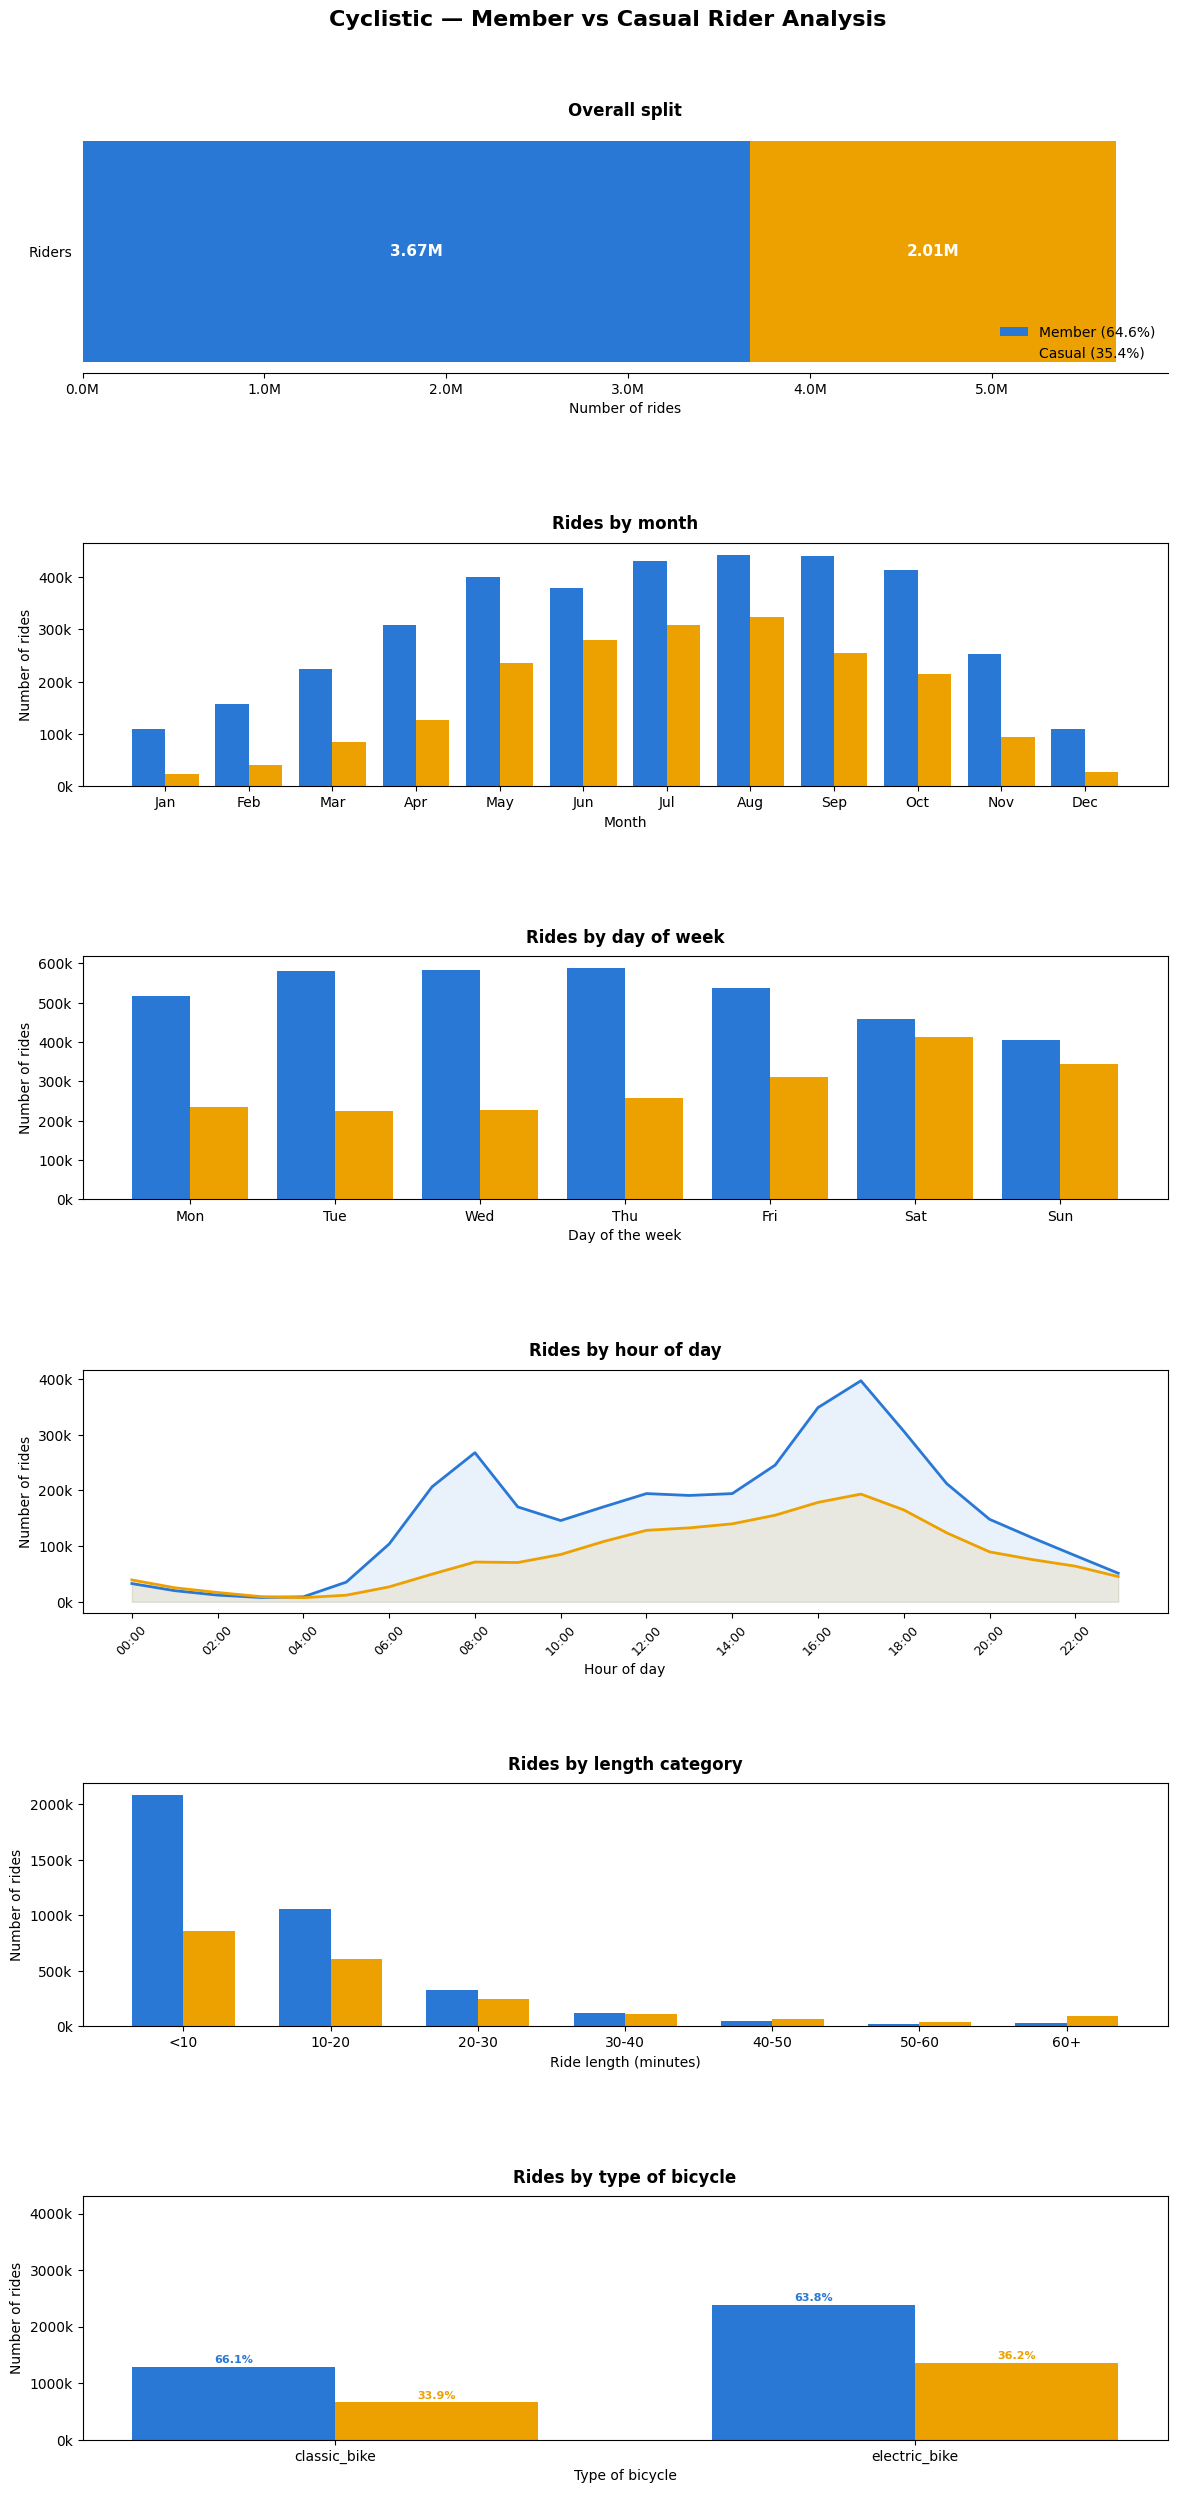

In [13]:
# Graphs

MEMBER_COLOR = '#2a78d6'
CASUAL_COLOR = '#eda100'

fig, axes = plt.subplots(
    6, 1,
    figsize=(14, 30),
    gridspec_kw={'hspace': 0.7}
)

fig.suptitle(
    'Cyclistic — Member vs Casual Rider Analysis',
    fontsize=16, fontweight='bold', y=0.92
)

width = 0.4

# ── 1. Overall split ──────────────────────────────────────────────────
ax0 = axes[0]
counts       = dataset_final['member_casual'].value_counts()
member_count = counts.get('member', 0)
casual_count = counts.get('casual', 0)
total        = member_count + casual_count

ax0.barh(
    ['Riders'], [member_count],
    color=MEMBER_COLOR, height=0.4,
    label=f'Member ({member_count/total*100:.1f}%)'
)
ax0.barh(
    ['Riders'], [casual_count], left=[member_count],
    color=CASUAL_COLOR, height=0.4,
    label=f'Casual ({casual_count/total*100:.1f}%)'
)
# Annotate counts inside bars
ax0.text(
    member_count / 2, 0,
    f'{member_count/1e6:.2f}M', ha='center', va='center',
    color='white', fontsize=11, fontweight='bold'
)
ax0.text(
    member_count + casual_count / 2, 0,
    f'{casual_count/1e6:.2f}M', ha='center', va='center',
    color='white', fontsize=11, fontweight='bold'
)
ax0.set_title('Overall split', fontweight='bold', pad=10)
ax0.set_xlabel('Number of rides', fontsize=10)
ax0.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
ax0.legend(loc='lower right', fontsize=10, frameon=False)
ax0.spines[['top', 'right', 'left']].set_visible(False)
ax0.tick_params(axis='y', left=False)

# ── 2. Rides by month ────────────────────────────────────────────────
ax1 = axes[1]
monthly = (
    dataset_final
    .groupby(['month_name', 'member_casual'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec'])
)

x = np.arange(len(monthly))

ax1.bar(x - width/2, monthly.get('member', [0]*len(monthly)), width,
        color=MEMBER_COLOR, label='Member', zorder=2)
ax1.bar(x + width/2, monthly.get('casual',  [0]*len(monthly)), width,
        color=CASUAL_COLOR, label='Casual',  zorder=2)
ax1.set_title('Rides by month', fontweight='bold', pad=10)
ax1.set_xlabel('Month', fontsize=10)
ax1.set_ylabel('Number of rides', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(monthly.index.tolist(), fontsize=10)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
)
# ── 3. Rides by day of week ──────────────────────────────────────────
ax2 = axes[2]
daily = (
    dataset_final
    .groupby(['day_name', 'member_casual'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])  # enforce correct order
)

x     = np.arange(len(daily))
width = 0.4

ax2.bar(x - width/2, daily.get('member', [0]*len(daily)), width,
        color=MEMBER_COLOR, label='Member', zorder=2)
ax2.bar(x + width/2, daily.get('casual',  [0]*len(daily)), width,
        color=CASUAL_COLOR, label='Casual',  zorder=2)
ax2.set_title('Rides by day of week', fontweight='bold', pad=10)
ax2.set_xlabel('Day of the week', fontsize=10)
ax2.set_ylabel('Number of rides', fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(daily.index.tolist(), fontsize=10)  # pulled from index directly
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
)
# ── 4. Rides by hour of day ──────────────────────────────────────────
ax3 = axes[3]
hourly = dataset_final.groupby(['hour', 'member_casual']).size().unstack(fill_value=0)

ax3.plot(hourly.index, hourly.get('member', [0]*24),
         color=MEMBER_COLOR, linewidth=2, label='Member')
ax3.fill_between(hourly.index, hourly.get('member', [0]*24),
                 color=MEMBER_COLOR, alpha=0.1)
ax3.plot(hourly.index, hourly.get('casual', [0]*24),
         color=CASUAL_COLOR, linewidth=2, label='Casual')
ax3.fill_between(hourly.index, hourly.get('casual', [0]*24),
                 color=CASUAL_COLOR, alpha=0.1)
ax3.set_title('Rides by hour of day', fontweight='bold', pad=10)
ax3.set_xlabel('Hour of day', fontsize=10)
ax3.set_ylabel('Number of rides', fontsize=10)
ax3.set_xticks(range(0, 24, 2))
ax3.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45, fontsize=9)
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
)


# ── 5. Rides by length category ──────────────────────────────────────
ax4 = axes[4]
ride_cat = (
    dataset_final
    .groupby(['ride_length_category', 'member_casual'], observed=True)
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
x     = np.arange(len(ride_cat))
width = 0.35

ax4.bar(x - width/2, ride_cat.get('member', [0]*len(ride_cat)), width,
        color=MEMBER_COLOR, label='Member', zorder=2)
ax4.bar(x + width/2, ride_cat.get('casual',  [0]*len(ride_cat)), width,
        color=CASUAL_COLOR, label='Casual',  zorder=2)
ax4.set_title('Rides by length category', fontweight='bold', pad=10)
ax4.set_xlabel('Ride length (minutes)', fontsize=10)
ax4.set_ylabel('Number of rides', fontsize=10)
ax4.set_xticks(x)
ax4.set_xticklabels(ride_cat.index.tolist(), fontsize=10)
ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
)


# ── 6. Rides by type of bicycle ──────────────────────────────────────
ax5 = axes[5]
ride_type = (
    dataset_final
    .groupby(['rideable_type', 'member_casual'], observed=True)
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

x     = np.arange(len(ride_type))
width = 0.35

member_vals = ride_type.get('member', [0]*len(ride_type))
casual_vals = ride_type.get('casual', [0]*len(ride_type))

# Total per bike type (for percentage calculation)
totals = member_vals + casual_vals

member_bars = ax5.bar(x - width/2, member_vals, width,
                      color=MEMBER_COLOR, label='Member', zorder=2)
casual_bars = ax5.bar(x + width/2, casual_vals, width,
                      color=CASUAL_COLOR, label='Casual', zorder=2)

# ── Add percentage labels ─────────────────────────────────────────────
for bar, val, total in zip(member_bars, member_vals, totals):
    if val > 0:
        ax5.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + totals.max() * 0.01,
            f'{val/total*100:.1f}%',
            ha='center', va='bottom',
            fontsize=8, color=MEMBER_COLOR, fontweight='bold'
        )

for bar, val, total in zip(casual_bars, casual_vals, totals):
    if val > 0:
        ax5.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + totals.max() * 0.01,
            f'{val/total*100:.1f}%',
            ha='center', va='bottom',
            fontsize=8, color=CASUAL_COLOR, fontweight='bold'
        )

# Extend y-axis slightly to make room for labels
ax5.set_ylim(0, totals.max() * 1.15)

ax5.set_title('Rides by type of bicycle', fontweight='bold', pad=10)
ax5.set_xlabel('Type of bicycle', fontsize=10)
ax5.set_ylabel('Number of rides', fontsize=10)
ax5.set_xticks(x)
ax5.set_xticklabels(ride_type.index.tolist(), fontsize=10)
ax5.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
)


plt.show()

<div style="background-color:#E8D6F0; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
The visualisations reveal clear and consistent differences in how members and casual riders use the Cyclistic service across every dimension examined — volume, timing, location, and ride duration. While members account for the majority of rides, the patterns suggest two fundamentally distinct user profiles rather than simply two sizes of the same behaviour. With that in mind, the following findings can be inferred from the data:
    
* **Members dominate, but casuals are a significant opportunity**
Members account for 64.6% of rides (3.67M) vs 35.4% casual (2.01M) — yet that 2 million casual rides represents a large pool of already-engaged users ripe for conversion.

* **Casual ridership is seasonal; members ride year-round**
Casual usage peaks sharply in July and August (~300k rides) before dropping to near zero in winter. Members show the same curve but far shallower, maintaining consistent usage throughout the year — suggesting members use Cyclistic as a utility, casuals as a leisure activity.

* **Members commute; casuals ride for leisure**
Members peak on weekdays with a classic double commuter spike at 08:00 and 17:00. Casuals peak on weekends with a gradual afternoon build to 15:00–17:00 and no morning spike whatsoever — the single clearest behavioural difference between the two groups.

* **Members take more rides; casuals take longer ones**
Members dominate the under-10-minute bracket (2.1M vs 850k). In the 30+ minute brackets casuals are proportionally more represented, consistent with shorter utility trips for members and longer leisure rides for casuals.

* **The two groups use completely different parts of the city**
Zero overlap exists between the top 10 member and casual start stations. Member stations cluster in the downtown business corridor; casual stations line the lakefront at tourist destinations — Navy Pier alone generates 38k starts, nearly double the busiest member station.

* **Bike type preferences are nearly identical**
Both groups favour classic bikes. Casuals use electric bikes marginally more (36.2% vs 33.9%), possibly reflecting a preference for lower-effort rides on longer leisure trips.


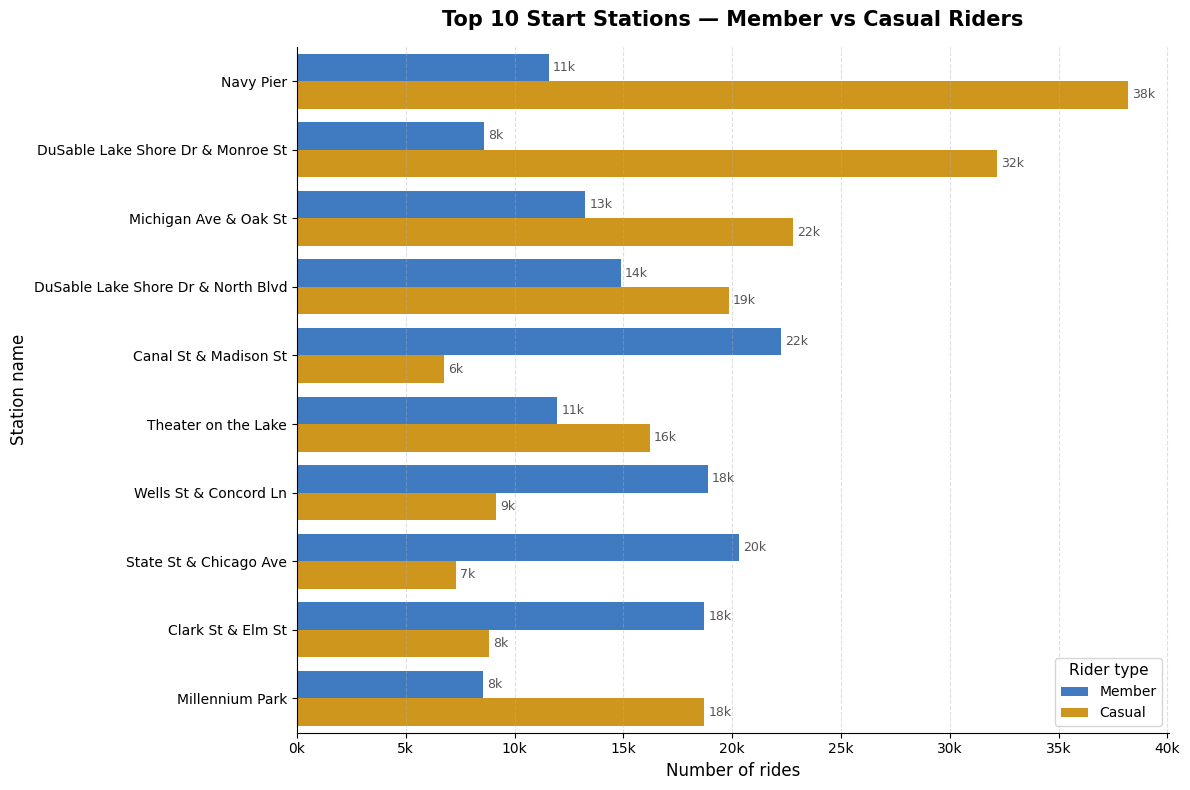

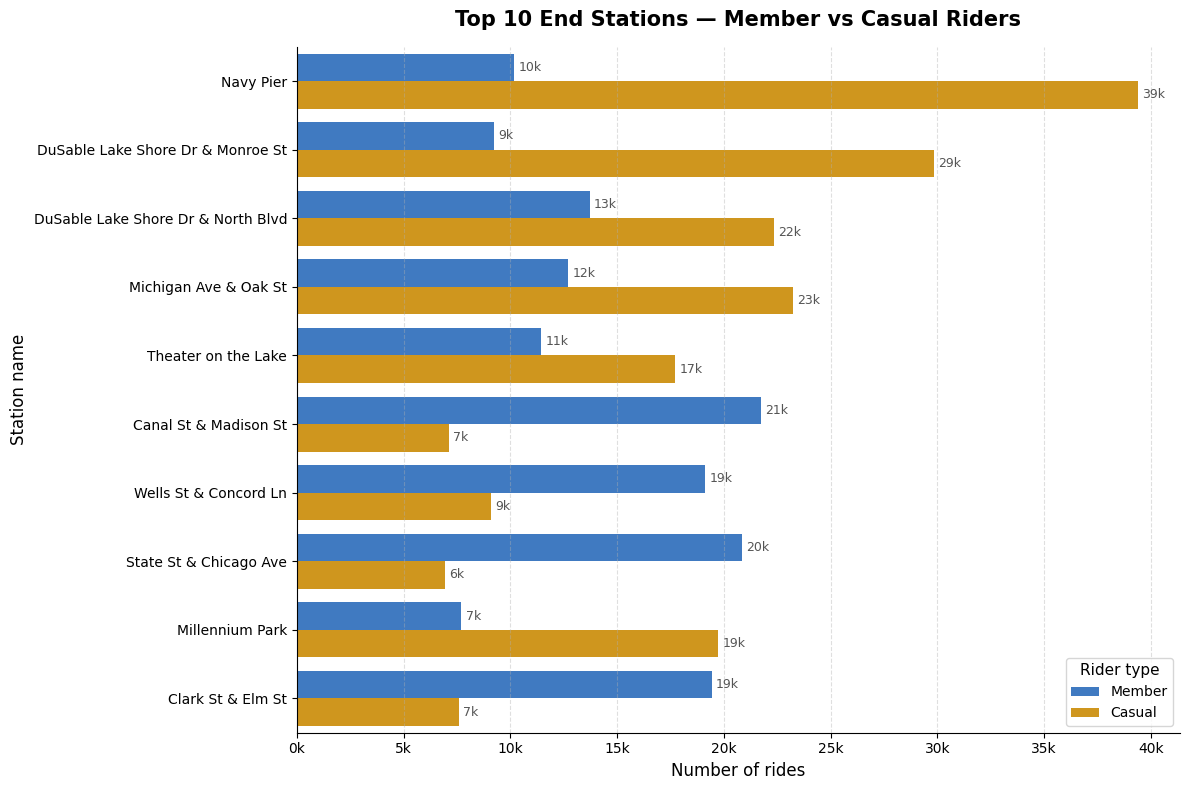

In [14]:
#Graphs

MEMBER_COLOR = '#2a78d6'
CASUAL_COLOR = '#eda100'
palette = {'member': MEMBER_COLOR, 'casual': CASUAL_COLOR}

def plot_top_stations(df, station_col, title, n=10):
    """
    Plots top N stations by ride count, split by member/casual.
    Excludes 'Unknown' entries automatically.

    Parameters:
        df:          source dataframe (dataset_v4)
        station_col: 'start_station_name' or 'end_station_name'
        title:       plot title string
        n:           number of top stations to show (default 10)
    """
    # Exclude unknown/missing stations
    cleaned = df[~df[station_col].isin(['Unknown', 'Other', ''])]

    # Get top N stations by total ride count
    top_stations = cleaned[station_col].value_counts().head(n).index

    # Filter to top N only
    plot_data = cleaned[cleaned[station_col].isin(top_stations)]

    fig, ax = plt.subplots(figsize=(12, 8))

    sns.countplot(
        y=station_col,
        hue='member_casual',
        hue_order=['member', 'casual'],
        data=plot_data,
        order=top_stations,
        palette=palette,
        ax=ax
    )

    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Number of rides', fontsize=12)
    ax.set_ylabel('Station name', fontsize=12)

    # Format x-axis ticks as thousands
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
    )

    # Add value labels to each bar
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: f'{int(x/1000)}k' if x > 0 else '',
                     padding=3, fontsize=9, color='#555')

    ax.legend(
        title='Rider type',
        title_fontsize=11,
        loc='lower right',
        labels=['Member', 'Casual']
    )
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{station_col}_top{n}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Plot top 10 start stations ──────────────────────────────────────
plot_top_stations(
    dataset_final,
    station_col='start_station_name',
    title='Top 10 Start Stations — Member vs Casual Riders'
)

# ── Plot top 10 end stations ────────────────────────────────────────
plot_top_stations(
    dataset_final,
    station_col='end_station_name',
    title='Top 10 End Stations — Member vs Casual Riders'
)

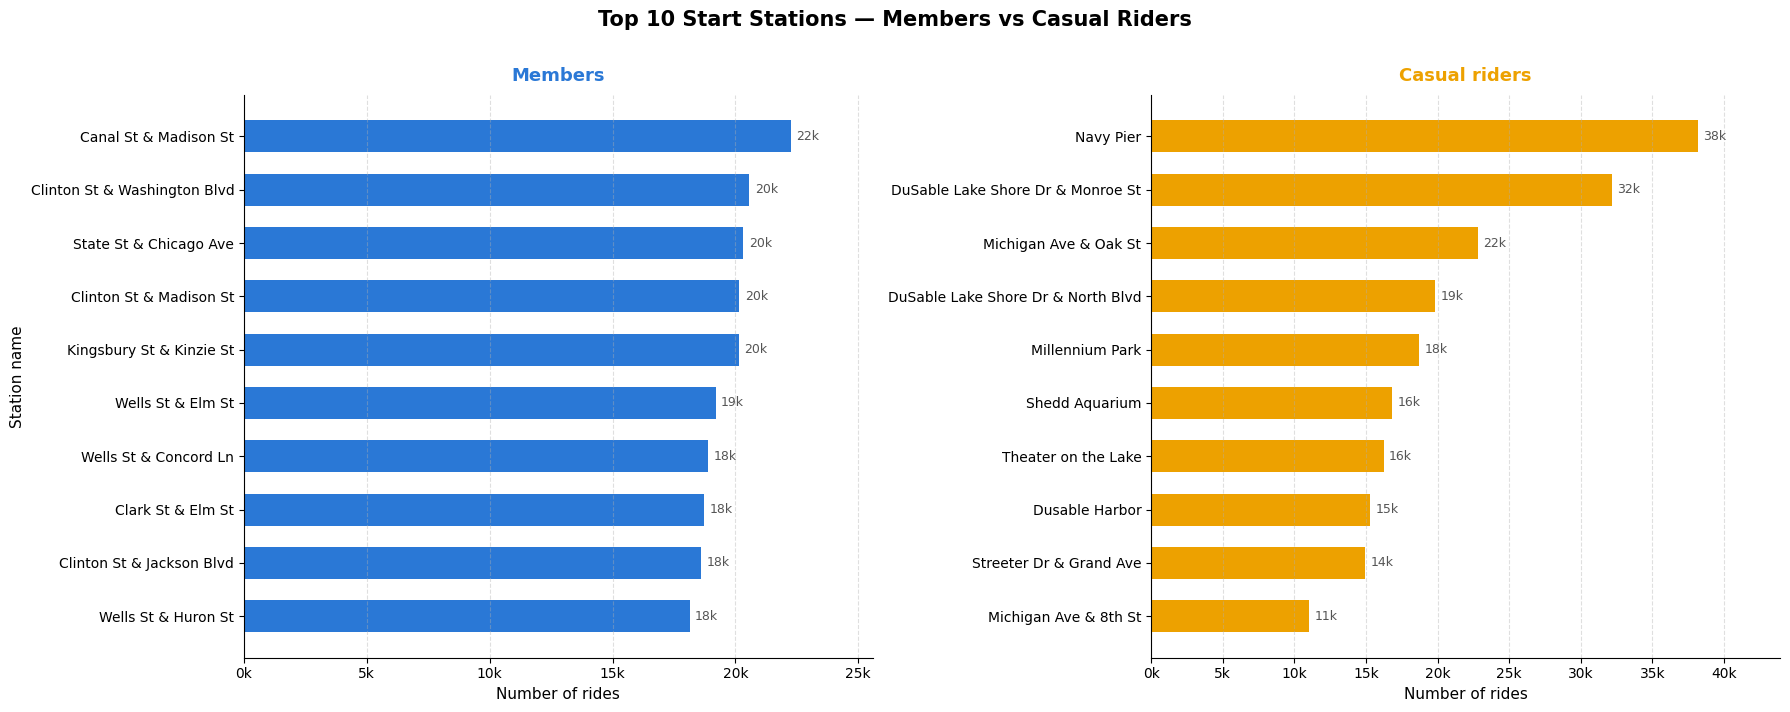

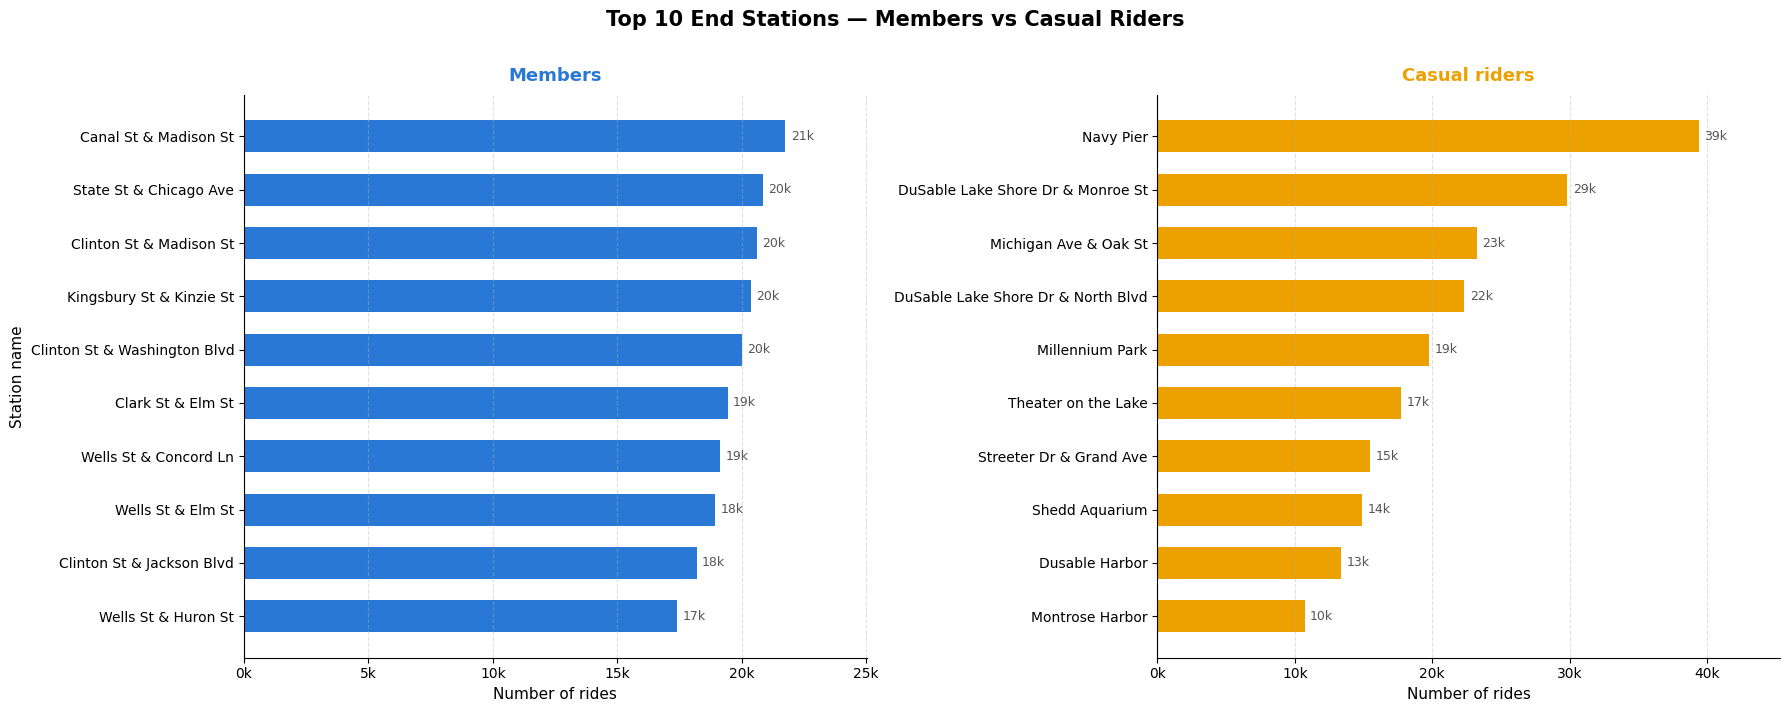

In [15]:
#Graphs
MEMBER_COLOR = '#2a78d6'
CASUAL_COLOR = '#eda100'

def plot_top_stations_by_type(df, station_col, rider_type, color, ax, n=10):
    """
    Plots top N stations for a single rider type (member OR casual).
    
    Parameters:
        df:          source dataframe (dataset_v4)
        station_col: 'start_station_name' or 'end_station_name'
        rider_type:  'member' or 'casual'
        color:       bar color
        ax:          matplotlib axis to plot on
        n:           number of top stations (default 10)
    """
    # Filter to rider type and exclude unknown stations
    filtered = df[
        (df['member_casual'] == rider_type) &
        (~df[station_col].isin(['Unknown', 'Other', '']))
    ]

    # Get top N stations by count for this rider type specifically
    top_stations = filtered[station_col].value_counts().head(n)

    # Plot horizontal bar
    bars = ax.barh(
        top_stations.index[::-1],   # reverse so #1 is at top
        top_stations.values[::-1],
        color=color,
        edgecolor='none',
        height=0.6
    )

    # Value labels on each bar
    for bar, val in zip(bars, top_stations.values[::-1]):
        ax.text(
            bar.get_width() + (top_stations.values.max() * 0.01),
            bar.get_y() + bar.get_height() / 2,
            f'{int(val/1000)}k',
            va='center', ha='left',
            fontsize=9, color='#555'
        )

    # Formatting
    ax.set_xlabel('Number of rides', fontsize=11)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k')
    )
    ax.set_xlim(0, top_stations.values.max() * 1.15)  # room for labels
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=10)


# ── Figure 1: Top 10 START stations ─────────────────────────────────
fig1, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(18, 7),
    sharey=False   # intentionally False — stations differ between groups
)
fig1.suptitle(
    'Top 10 Start Stations — Members vs Casual Riders',
    fontsize=15, fontweight='bold', y=1.01
)

plot_top_stations_by_type(dataset_final, 'start_station_name', 'member', MEMBER_COLOR, ax1)
plot_top_stations_by_type(dataset_final, 'start_station_name', 'casual', CASUAL_COLOR, ax2)

ax1.set_title('Members', fontsize=13, fontweight='bold', color=MEMBER_COLOR, pad=10)
ax2.set_title('Casual riders', fontsize=13, fontweight='bold', color=CASUAL_COLOR, pad=10)
ax1.set_ylabel('Station name', fontsize=11)
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('top10_start_stations.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 2: Top 10 END stations ───────────────────────────────────
fig2, (ax3, ax4) = plt.subplots(
    1, 2,
    figsize=(18, 7),
    sharey=False
)
fig2.suptitle(
    'Top 10 End Stations — Members vs Casual Riders',
    fontsize=15, fontweight='bold', y=1.01
)

plot_top_stations_by_type(dataset_final, 'end_station_name', 'member', MEMBER_COLOR, ax3)
plot_top_stations_by_type(dataset_final, 'end_station_name', 'casual', CASUAL_COLOR, ax4)

ax3.set_title('Members', fontsize=13, fontweight='bold', color=MEMBER_COLOR, pad=10)
ax4.set_title('Casual riders', fontsize=13, fontweight='bold', color=CASUAL_COLOR, pad=10)
ax3.set_ylabel('Station name', fontsize=11)
ax4.set_ylabel('')

plt.tight_layout()
plt.savefig('top10_end_stations.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
#Map
import folium

MEMBER_COLOR = '#2a78d6'
CASUAL_COLOR = '#eda100'
CHICAGO      = [41.8781, -87.6298]

# ── Get top 10 start stations per rider type ─────────────────────────
def get_top_stations(df, rider_type, station_col='start_station_name', n=10):
    """
    Returns a dataframe of top N stations for a given rider type,
    including avg lat/lng so we can place them on the map.
    """
    filtered = df[
        (df['member_casual'] == rider_type) &
        (~df[station_col].isin(['Unknown', 'Other', '']))
    ]

    # Count rides per station
    counts = (
        filtered[station_col]
        .value_counts()
        .head(n)
        .reset_index()
    )
    counts.columns = ['station_name', 'ride_count']

    # Get average lat/lng for each station
    coords = (
        filtered.groupby(station_col)[['start_lat', 'start_lng']]
        .mean()
        .reset_index()
        .rename(columns={station_col: 'station_name'})
    )

    return counts.merge(coords, on='station_name')


member_top = get_top_stations(dataset_final, 'member')
casual_top = get_top_stations(dataset_final, 'casual')

# ── Base map ──────────────────────────────────────────────────────────
m = folium.Map(
    location=CHICAGO,
    zoom_start=13,
    tiles='CartoDB positron'
)

# ── Layer groups ──────────────────────────────────────────────────────
member_layer      = folium.FeatureGroup(name='Top 10 — Member start stations',  show=True)
casual_layer      = folium.FeatureGroup(name='Top 10 — Casual start stations',  show=True)
member_heat_layer = folium.FeatureGroup(name='Member density heatmap',           show=False)
casual_heat_layer = folium.FeatureGroup(name='Casual density heatmap',           show=False)

# ── Helper: scale marker radius by rank ──────────────────────────────
def rank_radius(rank, min_r=10, max_r=22):
    """Rank 1 (most popular) gets max_r, rank 10 gets min_r."""
    return max_r - (rank / 10) * (max_r - min_r)


# ── Helper: build popup html ──────────────────────────────────────────
def build_popup(rank, station_name, ride_count, color, rider_label):
    return folium.Popup(
        f"""
        <div style="font-family:sans-serif; font-size:13px; min-width:200px">
            <b style="color:{color}">#{rank} {rider_label} Station</b>
            <hr style="margin:5px 0; border-color:#eee">
            <b>{station_name}</b><br><br>
            <b>Rides:</b> {int(ride_count):,}<br>
            <b>Rank:</b> #{rank} of top 10
        </div>
        """,
        max_width=240
    )


# ── Helper: add station markers to a layer ────────────────────────────
def add_station_markers(top_df, layer, color, rider_label):
    for rank, (_, row) in enumerate(top_df.iterrows(), start=1):
        r          = rank_radius(rank)
        size       = r * 2
        lat        = row['start_lat']
        lng        = row['start_lng']
        station    = row['station_name']
        ride_count = row['ride_count']

        # Single DivIcon that IS the circle + label + popup + tooltip
        folium.Marker(
            location=[lat, lng],
            popup=build_popup(rank, station, ride_count, color, rider_label),
            tooltip=f"#{rank} {rider_label} | {station} | {int(ride_count):,} rides",
            icon=folium.DivIcon(
                html=f"""
                    <div style="
                        width: {size}px;
                        height: {size}px;
                        border-radius: 50%;
                        background: {color};
                        border: 2.5px solid white;
                        box-shadow: 0 1px 4px rgba(0,0,0,0.3);
                        display: flex;
                        align-items: center;
                        justify-content: center;
                        font-family: sans-serif;
                        font-size: 11px;
                        font-weight: bold;
                        color: white;
                        cursor: pointer;
                        margin-left: -{r}px;
                        margin-top: -{r}px;
                    ">#{rank}</div>
                """,
                icon_size=(size, size),
                icon_anchor=(r, r)
            )
        ).add_to(layer)


# ── Rebuild member and casual layers ─────────────────────────────────
member_layer = folium.FeatureGroup(name='Top 10 — Member start stations', show=True)
casual_layer = folium.FeatureGroup(name='Top 10 — Casual start stations', show=True)

add_station_markers(member_top, member_layer, MEMBER_COLOR, 'Member')
add_station_markers(casual_top, casual_layer, CASUAL_COLOR, 'Casual')

member_layer.add_to(m)
casual_layer.add_to(m)


# ── Overlap markers (stations in BOTH top 10s) ────────────────────────
overlap = set(member_top['station_name']) & set(casual_top['station_name'])
if overlap:
    overlap_layer = folium.FeatureGroup(name='Shared top stations (both groups)', show=True)
    overlap_coords = (
        dataset_final[dataset_final['start_station_name'].isin(overlap)]
        .groupby('start_station_name')[['start_lat','start_lng']]
        .mean()
        .reset_index()
    )
    for _, row in overlap_coords.iterrows():
        folium.CircleMarker(
            location=[row['start_lat'], row['start_lng']],
            radius=14,
            color='white',
            weight=3,
            fill=True,
            fill_color='#2ecc71',
            fill_opacity=0.9,
            tooltip=f"Shared: {row['start_station_name']}",
            popup=folium.Popup(
                f"""<div style="font-family:sans-serif;font-size:13px">
                    <b style="color:#2ecc71">Shared top station</b>
                    <hr style="margin:5px 0">
                    {row['start_station_name']}<br>
                    <small>Appears in both member and casual top 10</small>
                </div>""",
                max_width=220
            )
        ).add_to(overlap_layer)
    overlap_layer.add_to(m)


# ── Legend ────────────────────────────────────────────────────────────
legend_html = f"""
<div style="
    position: fixed; bottom: 40px; left: 40px; z-index: 1000;
    background: white; padding: 14px 18px; border-radius: 10px;
    border: 1px solid #ddd; font-family: sans-serif; font-size: 13px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.15); min-width: 210px">
    <b style="font-size:14px">Top 10 start stations</b>
    <hr style="margin:8px 0; border-color:#eee">
    <div style="display:flex;align-items:center;gap:8px;margin-bottom:8px">
        <div style="width:16px;height:16px;border-radius:50%;
             background:{MEMBER_COLOR};border:2px solid white;
             box-shadow:0 0 0 1px {MEMBER_COLOR}"></div>
        <span>Member stations</span>
    </div>
    <div style="display:flex;align-items:center;gap:8px;margin-bottom:8px">
        <div style="width:16px;height:16px;border-radius:50%;
             background:{CASUAL_COLOR};border:2px solid white;
             box-shadow:0 0 0 1px {CASUAL_COLOR}"></div>
        <span>Casual stations</span>
    </div>
    <div style="display:flex;align-items:center;gap:8px;margin-bottom:12px">
        <div style="width:16px;height:16px;border-radius:50%;
             background:#2ecc71;border:2px solid white;
             box-shadow:0 0 0 1px #2ecc71"></div>
        <span>Shared by both</span>
    </div>
    <hr style="margin:8px 0; border-color:#eee">
    <span style="font-size:11px;color:#888;line-height:1.8">
        Marker size = popularity rank<br>
        #1 = largest marker<br>
        Click marker for details
    </span>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)

m.save('cyclistic_trip_map.html')
m

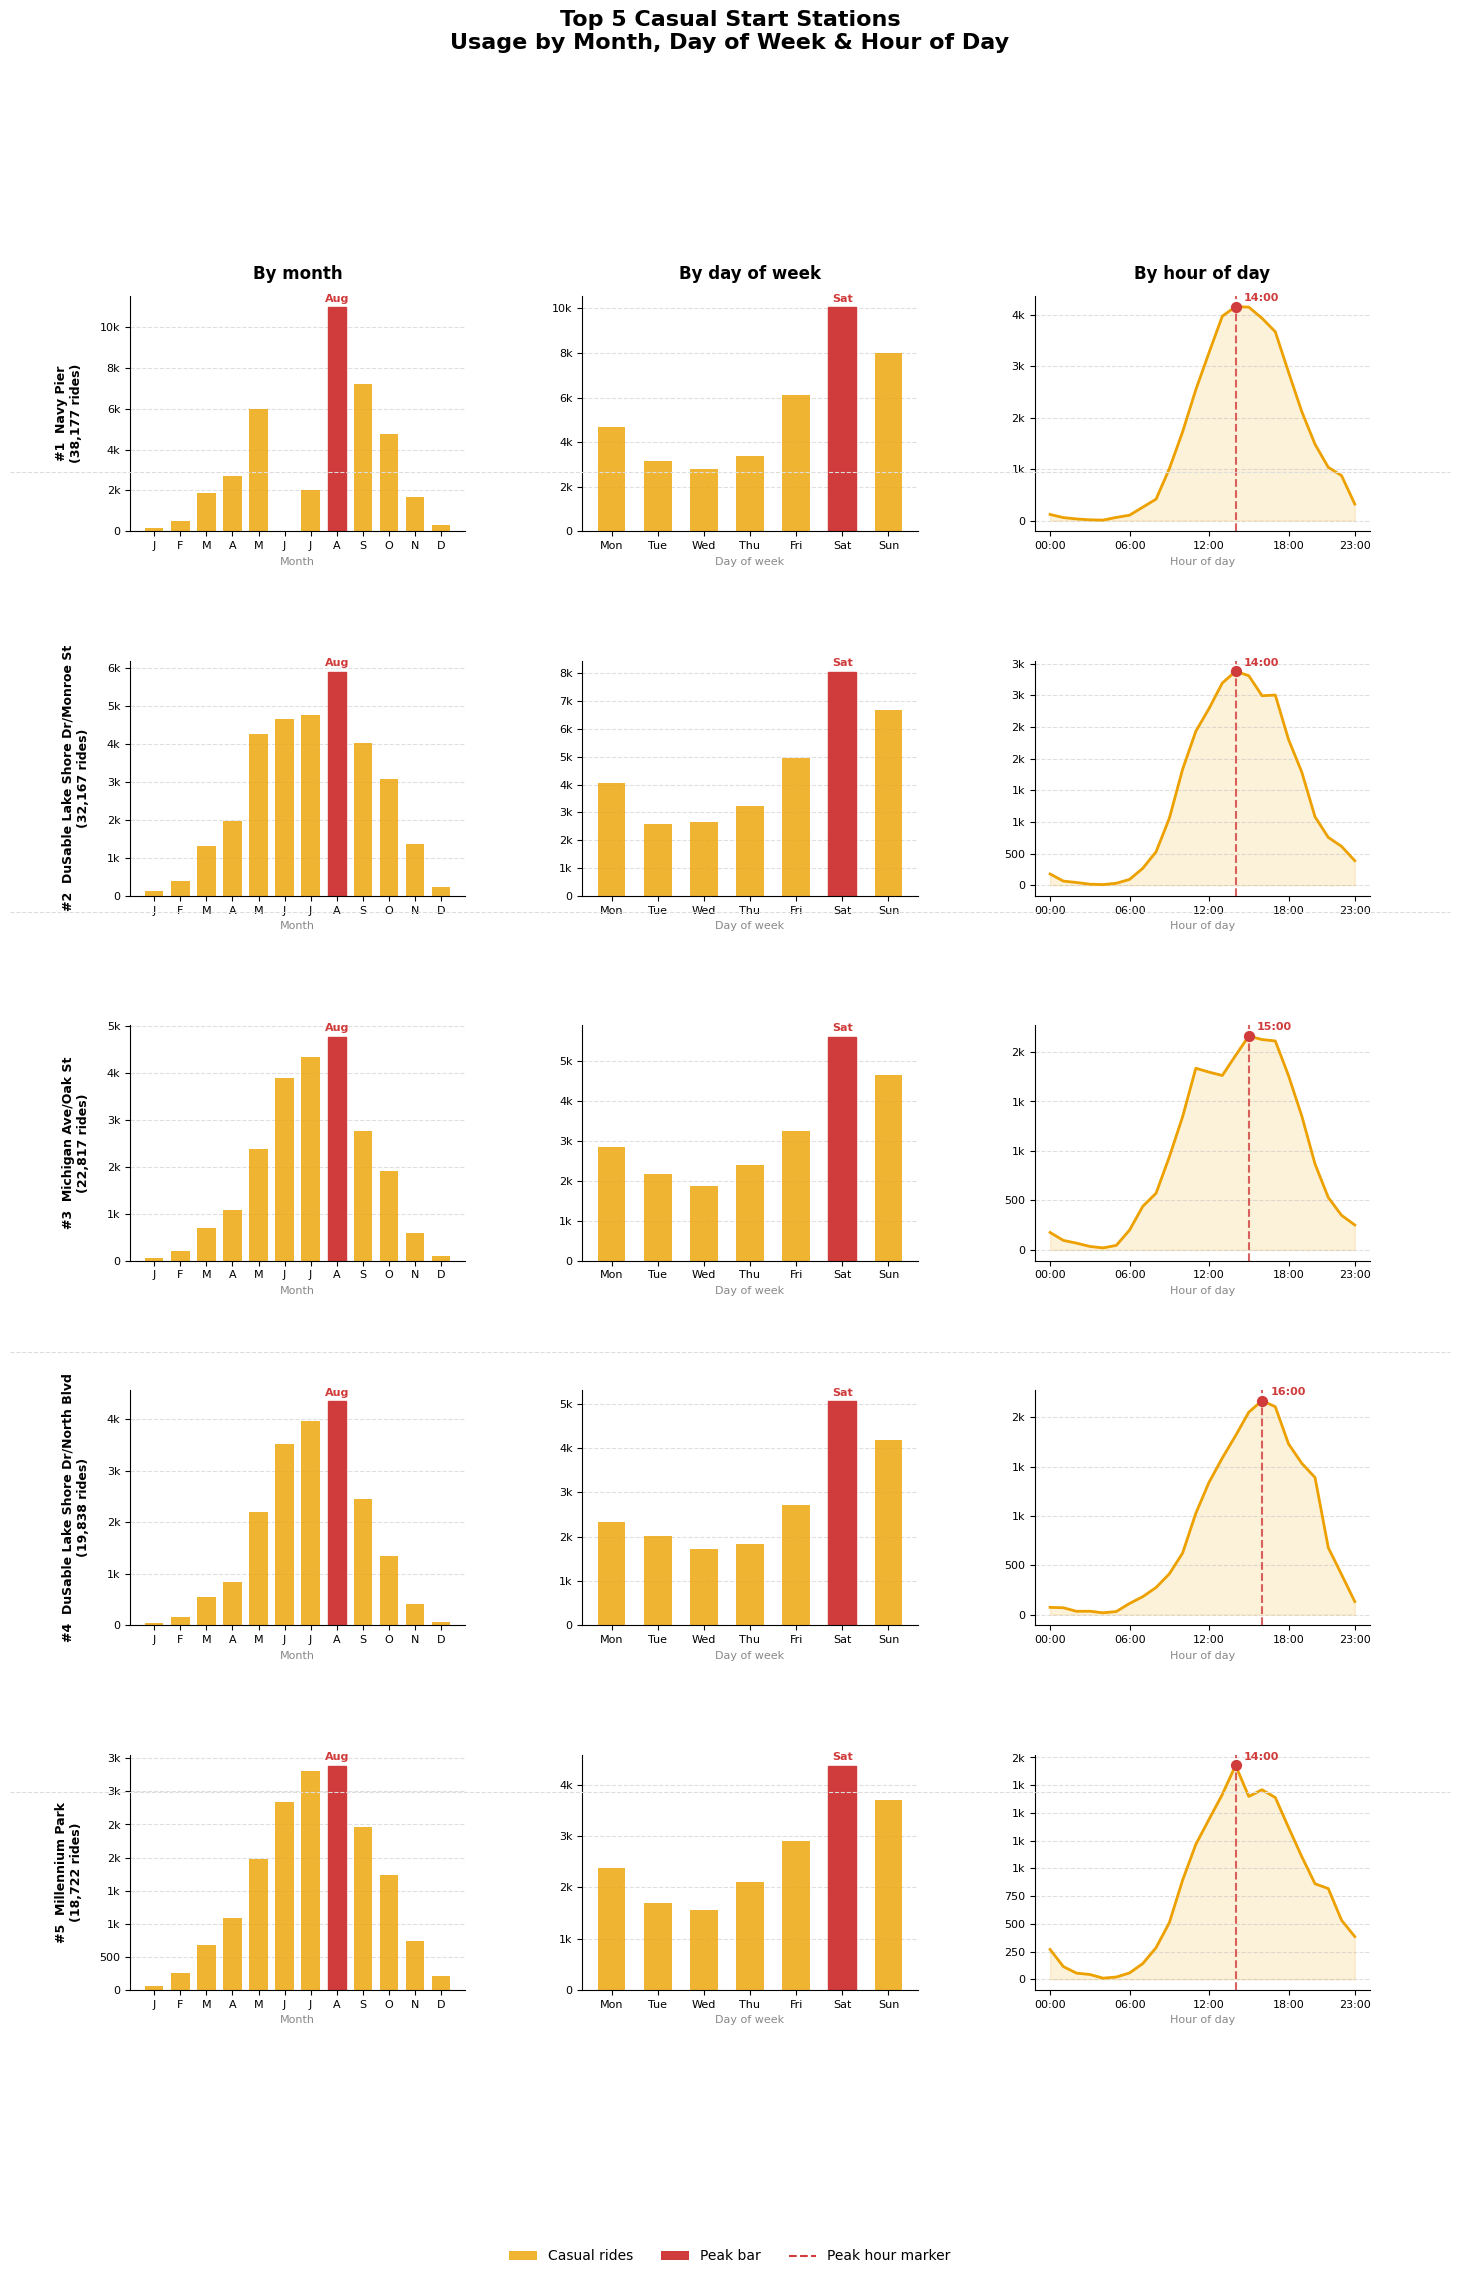

In [17]:
#Graphs

CASUAL_COLOR = '#eda100'
MONTH_NAMES  = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
DAY_NAMES    = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# ── Get top 5 casual start stations ──────────────────────────────────
casual_top5_names = casual_top['station_name'].head(5).tolist()

casual_top5_data = dataset_final[
    (dataset_final['member_casual'] == 'casual') &
    (dataset_final['start_station_name'].isin(casual_top5_names))
].copy()

casual_top5_data['station_short'] = (
    casual_top5_data['start_station_name']
    .str.replace(' & ', '/', regex=False)
    .str.slice(0, 32)
)

short_name_map = (
    casual_top5_data
    .drop_duplicates('start_station_name')
    .set_index('start_station_name')['station_short']
    .to_dict()
)

fig, axes = plt.subplots(
    5, 3,
    figsize=(16, 22),
    gridspec_kw={'hspace': 0.55, 'wspace': 0.35}
)

fig.suptitle(
    'Top 5 Casual Start Stations\nUsage by Month, Day of Week & Hour of Day',
    fontsize=16, fontweight='bold', y=1.01
)

col_titles = ['By month', 'By day of week', 'By hour of day']
for col_idx, title in enumerate(col_titles):
    axes[0, col_idx].set_title(title, fontsize=12, fontweight='bold', pad=12)

for row_idx, station_name in enumerate(casual_top5_names):
    short        = short_name_map.get(station_name, station_name[:32])
    station_data = casual_top5_data[
        casual_top5_data['start_station_name'] == station_name
    ]
    rank        = row_idx + 1
    total_rides = len(station_data)

    axes[row_idx, 0].set_ylabel(
        f'#{rank}  {short}\n({total_rides:,} rides)',
        fontsize=9, fontweight='bold',
        labelpad=12, loc='center'
    )

    # ── Col 0: by month ───────────────────────────────────────────
    ax = axes[row_idx, 0]
    monthly = (
        station_data
        .groupby('month_name', observed=True)        # ← month_name
        .size()
        .reindex(MONTH_NAMES, fill_value=0)          # ← reindex by name
    )
    bars = ax.bar(
        range(1, 13), monthly.values,
        color=CASUAL_COLOR, alpha=0.8, width=0.7, zorder=2
    )
    peak_month_idx = monthly.values.argmax()         # ← positional index
    bars[peak_month_idx].set_color('#d03b3b')
    bars[peak_month_idx].set_alpha(1.0)

    ax.annotate(
        MONTH_NAMES[peak_month_idx],
        xy=(peak_month_idx + 1, monthly.values[peak_month_idx]),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=8, color='#d03b3b', fontweight='bold'
    )
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([m[0] for m in MONTH_NAMES], fontsize=8)
    ax.set_xlabel('Month', fontsize=8, color='#888')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'
    ))
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

    # ── Col 1: by day of week ─────────────────────────────────────
    ax = axes[row_idx, 1]
    daily = (
        station_data
        .groupby('day_name', observed=True)          # ← day_name
        .size()
        .reindex(DAY_NAMES, fill_value=0)            # ← reindex by name
    )
    bars = ax.bar(
        range(1, 8), daily.values,
        color=CASUAL_COLOR, alpha=0.8, width=0.6, zorder=2
    )
    peak_day_idx = daily.values.argmax()             # ← positional index
    bars[peak_day_idx].set_color('#d03b3b')
    bars[peak_day_idx].set_alpha(1.0)

    ax.annotate(
        DAY_NAMES[peak_day_idx],
        xy=(peak_day_idx + 1, daily.values[peak_day_idx]),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=8, color='#d03b3b', fontweight='bold'
    )
    ax.set_xticks(range(1, 8))
    ax.set_xticklabels(DAY_NAMES, fontsize=8)
    ax.set_xlabel('Day of week', fontsize=8, color='#888')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'
    ))
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

    # ── Col 2: by hour of day ─────────────────────────────────────
    ax = axes[row_idx, 2]
    hourly = (
        station_data
        .groupby('hour', observed=True)              # ← hour stays numeric
        .size()
        .reindex(range(0, 24), fill_value=0)
    )
    ax.plot(range(0, 24), hourly.values,
            color=CASUAL_COLOR, linewidth=2, zorder=2)
    ax.fill_between(range(0, 24), hourly.values,
                    color=CASUAL_COLOR, alpha=0.15)

    peak_hour_idx = hourly.values.argmax()
    ax.axvline(peak_hour_idx, color='#d03b3b', linewidth=1.5,
               linestyle='--', alpha=0.8, zorder=3)
    ax.scatter([peak_hour_idx], [hourly.values[peak_hour_idx]],
               color='#d03b3b', zorder=4, s=50)
    ax.annotate(
        f'{peak_hour_idx:02d}:00',
        xy=(peak_hour_idx, hourly.values[peak_hour_idx]),
        xytext=(6, 4), textcoords='offset points',
        ha='left', fontsize=8, color='#d03b3b', fontweight='bold'
    )
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xticklabels(['00:00','06:00','12:00','18:00','23:00'], fontsize=8)
    ax.set_xlabel('Hour of day', fontsize=8, color='#888')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'
    ))
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

# ── Dividers ──────────────────────────────────────────────────────────
for row_idx in range(1, 5):
    line = plt.Line2D(
        [0.05, 0.95], [1 - (row_idx / 5)],
        transform=fig.transFigure,
        color='#ddd', linewidth=0.8, linestyle='--'
    )
    fig.add_artist(line)

# ── Legend ────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=CASUAL_COLOR, alpha=0.8, label='Casual rides'),
    Patch(facecolor='#d03b3b',               label='Peak bar'),
    Line2D([0], [0], color='#d03b3b', linewidth=1.5,
           linestyle='--',                   label='Peak hour marker'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center', ncol=3, fontsize=10,
    frameon=False, bbox_to_anchor=(0.5, -0.02)
)

plt.show()



The Divvy station at Navy Pier did not close in June 2025; instead, it was expanded. The City of Chicago Department of Transportation upgraded the popular Polk Bros Park location by increasing its capacity from 47 to 72 docks to accommodate high rider demand. 

# **Share**
<div style="background-color:#FEF3CD; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
Overview
The Share phase defines how the findings from the analysis are communicated to Cyclistic's key stakeholders — primarily the Director of Marketing, Lily Moreno, and the executive team who will make the final decision on approving the proposed marketing strategy. Because the executive team is described as detail-oriented and data-driven, all recommendations must be grounded in clear evidence and supported by professional visualizations.
Guiding Principles for Presentation
The analysis findings are communicated with the following principles in mind:
Clarity over complexity. The visualizations were designed to be immediately readable without requiring a technical background. Consistent colour coding (blue for members, amber for casuals) is maintained across every chart, map, and table so that stakeholders can orient themselves instantly regardless of which visual they are looking at.
Evidence before recommendation. Every claim made in the presentation is anchored to a specific chart or data point produced during the analysis phase. No recommendation is made without a supporting finding, and no finding is stated without a corresponding visualization.
Narrative structure. The findings are presented in a logical sequence that builds a coherent story: who the two groups are → when they ride → where they ride → how long they ride → what this means for the business. This structure allows the executive team to follow the reasoning from data to conclusion naturally.
Key Visualizations Produced
The following visualizations were created to support the presentation of findings:
VisualizationKey insight communicatedOverall split barMembers 64.6% vs Casuals 35.4% of total ridesRides by monthCasual ridership is seasonal; member ridership is consistentRides by day of weekMembers peak weekdays; casuals peak weekendsRides by hour of dayMembers show commute double-peak; casuals show leisure afternoon peakRides by length categoryMembers take shorter, more frequent tripsRides by bike typeBoth groups prefer classic bikes; casuals use electric slightly moreTop 10 start/end stationsCompletely different stations for each groupGeographic mapZero geographic overlap — members downtown, casuals on lakefrontTop 5 casual station temporal chartsSummer and weekend leisure spikes at tourist destinations
Limitations to Acknowledge
The following limitations are disclosed transparently to stakeholders:

No personally identifiable information was available, meaning it is not possible to determine whether casual riders live within the service area, their income level, or whether any individual purchased multiple single-ride passes.
Station name recovery via GPS coordinates left a portion of records labelled 'Unknown', which were excluded from station-level analysis but retained for all temporal and duration analyses.
Distance calculations use straight-line Haversine distance rather than actual cycling route distance, so distance figures represent minimum possible trip distance rather than true distance cycled.
Circular trips (where start and end station are the same) show zero distance despite covering real ground, which may slightly understate casual rider distances given their higher leisure usage.

# **Act**
<div style="background-color:#D6EFF0; padding: 20px; border-radius:15px; font-size:20px; font-family:Arial; line-height: 1.7em;">
Overview
Based on the analysis findings, the following three recommendations are proposed to Lily Moreno and the Cyclistic executive team. Each recommendation is directly tied to a specific behavioural difference identified in the data and is designed to convert casual riders into annual members.

Recommendation 1 — Launch a targeted summer lakefront campaign
What the data shows: Casual riders peak sharply in July and August, with usage concentrated almost entirely along the lakefront tourist corridor. Navy Pier alone generates nearly 40,000 casual starts — almost double the busiest member station. The top 10 casual stations include Navy Pier, DuSable Lake Shore Drive, Millennium Park, Shedd Aquarium, and Theater on the Lake — all leisure and tourism destinations with no overlap whatsoever with member stations.
What to do: Design and deploy a targeted marketing campaign specifically for the summer months (May through August) at and around the top casual stations. This should include physical marketing at docking stations at Navy Pier, Millennium Park, and DuSable Lake Shore Drive, as well as geofenced digital advertising targeting users in those areas. The campaign messaging should emphasise the value of an annual membership for someone who already uses Cyclistic regularly during the warmer months — for example, highlighting cost savings for riders who take multiple rides per visit.
Why it will work: These casual riders have already chosen Cyclistic and are already engaged with the product. They are not being acquired from scratch — they simply need a compelling reason to commit. Reaching them at the exact location and time of peak engagement maximises relevance and conversion likelihood.

Recommendation 2 — Introduce a weekend or leisure membership tier
What the data shows: Casual riders are heavily concentrated on weekends — Saturday and Sunday account for the largest casual ride volumes, while member usage actually dips on those days. Casual riders peak in the afternoon (15:00–17:00) with no morning commute spike, confirming that their usage pattern is fundamentally leisure-driven rather than utility-driven. A standard annual membership, implicitly designed around daily commuting, may simply not feel relevant or valuable to a rider who only uses the service on weekend afternoons in summer.
What to do: Work with the product and finance teams to explore a weekend membership or leisure membership tier — a lower-cost annual product that offers unlimited rides on weekends and public holidays. This removes the psychological barrier of paying for a full commuter membership when the rider's needs are purely recreational. The digital marketing campaign promoting this tier should run on social media platforms (Instagram, TikTok) targeting Chicago residents aged 18–45, with creative content showing leisure and sightseeing use cases rather than commuting.
Why it will work: Price and perceived relevance are the two most common barriers to membership conversion. A leisure tier directly addresses both — it costs less and it matches the actual behaviour of the casual rider segment. Even if the revenue per user is lower than a full annual membership, converting a casual rider to any membership is a significant step up in lifetime value and loyalty.

Recommendation 3 — Use digital media to highlight year-round value and cost savings
What the data shows: Casual ridership falls dramatically in winter — dropping to near zero in December and January — while member ridership remains relatively stable year-round. This suggests casual riders either do not consider cycling viable in winter or do not feel the cost of a full membership is justified given their seasonal usage. However, the data also shows that members who do ride in winter maintain consistent patterns, suggesting that winter cycling in Chicago is entirely feasible for motivated riders.
What to do: Develop a digital media campaign — across email, social media, and in-app notifications — that specifically targets casual riders in the late summer and early autumn window (August through October), just before casual usage begins to decline. The campaign should present a clear cost comparison showing how many single rides or day passes a casual rider would need to break even on an annual membership, making the financial case concrete and personalised. It should also address the winter barrier directly, showcasing real member stories and practical content around year-round cycling in Chicago (e.g. cycling routes, weather tips, electric bike availability).
Why it will work: Casual riders in August and September are at peak engagement with the product and are most receptive to messaging about it. Reaching them just before the winter drop-off — when the value of locking in a membership before prices potentially rise is highest — creates urgency. Pairing a financial argument with social proof from existing members directly counters the two most likely objections: cost and seasonal relevance.

Summary of Recommendations
RecommendationTarget segmentChannelTiming1. Summer lakefront campaignCasual riders at tourist stationsPhysical + geofenced digitalMay–August2. Weekend/leisure membership tierWeekend recreational casual ridersSocial media (Instagram, TikTok)Year-round launch3. Autumn digital cost-saving campaignAll casual ridersEmail, in-app, social mediaAugust–October

Final Statement
The data consistently tells the same story from every angle examined — casual riders and annual members are using Cyclistic for fundamentally different purposes, at different times, in different parts of the city. Members are commuters who rely on Cyclistic as a daily utility. Casual riders are leisure users who engage with the service seasonally, on weekends, and at tourist destinations. Bridging that gap requires not just marketing messaging but potentially a product offering that meets casual riders where they actually are — rather than asking them to adopt a membership designed for a usage pattern that does not reflect their own.
The three recommendations above are designed to do exactly that: reach casual riders at the right place, at the right time, with the right offer.